# Import libraries

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import string
import os

print("="*80)
print("✅ Library berhasil di-import!")
print("="*80)

✅ Library berhasil di-import!


# Baca file CSV

In [2]:
df = pd.read_csv('../data/raw/Data_kasuskriminal_sungai_pinyuh.csv')

print("="*80)
print("DATA PREPARATION - KASUS KRIMINAL SUNGAI PINYUH")
print("="*80)

DATA PREPARATION - KASUS KRIMINAL SUNGAI PINYUH


# 1. Tampilkan informasi awal

In [3]:
print("\n=== INFORMASI AWAL DATA ===")
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
print(f"\nNama kolom: {df.columns.tolist()}")
print(f"\n5 baris pertama:")
print(df.head())


=== INFORMASI AWAL DATA ===
Jumlah baris: 1050
Jumlah kolom: 10

Nama kolom: ['NO', 'NO & TGL LAPORAN POLISI', 'PERKARA', 'TKP', 'PELAPOR', 'TERLAPOR', 'MO', 'BARANG BUKTI', 'PROSES', 'KET']

5 baris pertama:
   NO                            NO & TGL LAPORAN POLISI       PERKARA  \
0   1  LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...  Penganiayaan   
1   2  LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...     Pencurian   
2   3  LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...     Pencurian   
3   4  LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...       Narkoba   
4   5  LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...       Narkoba   

                                                 TKP          PELAPOR  \
0  Dusun Melati, Sungai Purun Kecil, Kec. Sungai ...     EMIL PERMATA   
1  Gg. Usaha RT 20/RW 09, Sungai Batang, Kec. Sun...           DINI     
2  Jl. Raya Nusapati RT 09/RW 05, Sungai Purun Ke...      ALFIN LIANG   
3  Dusun Sejahtera, Sungai Batang, Kec. Sungai Pi... 

# 2. Hapus kolom 'NO' (kolom nomor urut pertama)

In [4]:
df = df.drop(columns=['NO'])
print(f"\n✓ Kolom 'NO' telah dihapus")
print(f"  Jumlah kolom setelah penghapusan: {len(df.columns)}")
df.head()


✓ Kolom 'NO' telah dihapus
  Jumlah kolom setelah penghapusan: 9


,NO & TGL LAPORAN POLISI,PERKARA,TKP,PELAPOR,TERLAPOR,MO,BARANG BUKTI,PROSES,KET
0,LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Penganiayaan,"Dusun Melati, Sungai Purun Kecil, Kec. Sungai ...",EMIL PERMATA,LIE,Pelaku merasa tersinggung dengan tatapan korba...,Hasil Visum et Repertum,Sidik,Tipiring Sidang PN
1,LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Pencurian,"Gg. Usaha RT 20/RW 09, Sungai Batang, Kec. Sun...",DINI,PASARIBU,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",Perhiasan emas,Sidik,P. 21 Tahap II
2,LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Pencurian,"Jl. Raya Nusapati RT 09/RW 05, Sungai Purun Ke...",ALFIN LIANG,FIKA,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",1 buah HP,Sidik,Tahap I
3,LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Narkoba,"Dusun Sejahtera, Sungai Batang, Kec. Sungai Pi...",LESTARI IRAWAN,MANSUR FAJAR,Petugas mencurigai gerak-gerik pelaku di pingg...,Timbangan digital,Dalam Lidik,Lidik
4,LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Narkoba,"Gg. Famili, Desa/Kel. Peniraman, Kec. Sungai P...",EKO YASIN NG,DADANG KARIM,Petugas mencurigai gerak-gerik pelaku di pingg...,Paket klip sabu,Sidik,P. 21 Tahap II


# 3. Pisahkan kolom 'NO & TGL LAPORAN POLISI' menjadi 2 kolom

In [5]:
# Tampilkan beberapa sampel kolom yang akan diproses
print("\n=== SAMPEL DATA MENTAH (Kolom 'NO & TGL LAPORAN POLISI') ===")
for i, val in enumerate(df['NO & TGL LAPORAN POLISI'].head(15)):
    print(f"{i+1}. {val}")

def parse_no_tanggal(value):
    """
    Memisahkan nomor laporan polisi dan tanggal dari teks
    Menangani format 'tgl' dan 'tgl.'
    """
    if pd.isna(value) or value == '':
        return None, None
    
    text = str(value)
    
    # Pattern: mencari kata 'tgl' atau 'tgl.' diikuti tanggal
    # Contoh: "... tgl 1 Januari 2021" atau "... tgl. 1 Januari 2021"
    pattern = r'(LP.+?)\s+tgl\.?\s+(.+)'
    match = re.search(pattern, text, re.IGNORECASE)
    
    if match:
        no_laporan = match.group(1).strip()
        tanggal = match.group(2).strip()
        return no_laporan, tanggal
    
    # Jika tidak ada pola 'tgl', seluruh teks dianggap sebagai nomor laporan
    return text.strip(), None



=== SAMPEL DATA MENTAH (Kolom 'NO & TGL LAPORAN POLISI') ===
1. LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 1 Januari 2021
2. LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 1 Januari 2021
3. LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 4 Januari 2021
4. LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 5 Januari 2021
5. LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 5 Januari 2021
6. LP/B/06/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 5 Januari 2021
7. LP/B/07/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 6 Januari 2021
8. LP/B/08/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 9 Januari 2021
9. LP/B/09/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 13 Januari 2021
10. LP/B/10/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 15 Januari 2021
11. LP/B/11/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 16 Januari 2021
12. LP/B/12/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 20 Januari 2021
13. LP/B/13/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 20 Januari 2021
14. LP/B/14/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh tgl 20 Ja

In [6]:
# Terapkan fungsi ke kolom
print("\n" + "="*80)
print("MEMPROSES PEMISAHAN NOMOR LAPORAN DAN TANGGAL...")
print("="*80)

parse_results = df['NO & TGL LAPORAN POLISI'].apply(
    lambda x: pd.Series(parse_no_tanggal(x))
)
parse_results.columns = ['NO_LAPORAN', 'TGL_LAPORAN']

# Gabungkan ke dataframe
df = pd.concat([df, parse_results], axis=1)

# Hapus kolom 'NO & TGL LAPORAN POLISI' yang sudah dipisah
df = df.drop(columns=['NO & TGL LAPORAN POLISI'])

# Tampilkan hasil parsing untuk pengecekan
print("\n=== HASIL PARSING (10 data pertama) ===")
for idx in range(min(10, len(df))):
    print(f"{idx+1}.")
    print(f"  NO_LAPORAN : {df['NO_LAPORAN'].iloc[idx]}")
    print(f"  TGL_LAPORAN: {df['TGL_LAPORAN'].iloc[idx]}")
    print()

# Cek data yang TGL_LAPORAN-nya kosong
no_tanggal = df[df['TGL_LAPORAN'].isna()]
if len(no_tanggal) > 0:
    print(f"\n⚠️ Terdapat {len(no_tanggal)} data yang tidak memiliki tanggal:")
    for idx, row in no_tanggal.iterrows():
        print(f"  - {row['NO_LAPORAN'][:100]}...")

# Atur urutan kolom
cols = ['NO_LAPORAN', 'TGL_LAPORAN'] + [c for c in df.columns if c not in ['NO_LAPORAN', 'TGL_LAPORAN']]
df = df[cols]



MEMPROSES PEMISAHAN NOMOR LAPORAN DAN TANGGAL...

=== HASIL PARSING (10 data pertama) ===
1.
  NO_LAPORAN : LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 1 Januari 2021

2.
  NO_LAPORAN : LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 1 Januari 2021

3.
  NO_LAPORAN : LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 4 Januari 2021

4.
  NO_LAPORAN : LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 5 Januari 2021

5.
  NO_LAPORAN : LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 5 Januari 2021

6.
  NO_LAPORAN : LP/B/06/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 5 Januari 2021

7.
  NO_LAPORAN : LP/B/07/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 6 Januari 2021

8.
  NO_LAPORAN : LP/B/08/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 9 Januari 2021

9.
  NO_LAPORAN : LP/B/09/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh
  TGL_LAPORAN: 13 Januari 2021

10.
  NO_LAPORAN : LP/B/10/I/2021/Kalbar/Res Mpw/Sek Sui Pinyu

In [7]:

# Tampilkan hasil akhir
print("\n" + "="*80)
print("HASIL AKHIR DATA PREPARATION")
print("="*80)

print(f"\n✓ Jumlah baris: {len(df)}")
print(f"✓ Jumlah kolom: {len(df.columns)}")
print(f"\n✓ Nama kolom: {df.columns.tolist()}")

print("\n=== 10 BARIS PERTAMA ===")
print(df[['NO_LAPORAN', 'TGL_LAPORAN', 'PERKARA']].head(10))

# Verifikasi
print("\n=== VERIFIKASI ===")
print(f"NO_LAPORAN kosong: {df['NO_LAPORAN'].isna().sum()}")
print(f"TGL_LAPORAN kosong: {df['TGL_LAPORAN'].isna().sum()}")
print(f"Unik NO_LAPORAN: {df['NO_LAPORAN'].nunique()}")

print("\n" + "="*80)
print("DATA PREPARATION SELESAI")
print("="*80)


HASIL AKHIR DATA PREPARATION

✓ Jumlah baris: 1050
✓ Jumlah kolom: 10

✓ Nama kolom: ['NO_LAPORAN', 'TGL_LAPORAN', 'PERKARA', 'TKP', 'PELAPOR', 'TERLAPOR', 'MO', 'BARANG BUKTI', 'PROSES', 'KET']

=== 10 BARIS PERTAMA ===
                                     NO_LAPORAN      TGL_LAPORAN       PERKARA
0  LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   1 Januari 2021  Penganiayaan
1  LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   1 Januari 2021     Pencurian
2  LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   4 Januari 2021     Pencurian
3  LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   5 Januari 2021       Narkoba
4  LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   5 Januari 2021       Narkoba
5  LP/B/06/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   5 Januari 2021     Pencurian
6  LP/B/07/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   6 Januari 2021   Penggelapan
7  LP/B/08/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh   9 Januari 2021     Perusakan
8  LP/B/09/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh  13 Januari 2021   

# 4. ANALISIS GRAFIK PERKARA - KASUS KRIMINAL SUNGAI PINYUH

In [8]:
print("="*80)
print("ANALISIS GRAFIK PERKARA - KASUS KRIMINAL SUNGAI PINYUH")
print("="*80)

# Tampilkan informasi awal
print(f"\nJumlah total kasus: {len(df)}")
print(f"Jenis perkara unik: {df['PERKARA'].nunique()}")

# Hitung frekuensi setiap jenis perkara
perkara_counts = df['PERKARA'].value_counts()
perkara_percent = df['PERKARA'].value_counts(normalize=True) * 100

print("\n=== FREKUENSI PERKARA ===")
print(perkara_counts)

ANALISIS GRAFIK PERKARA - KASUS KRIMINAL SUNGAI PINYUH

Jumlah total kasus: 1050
Jenis perkara unik: 12

=== FREKUENSI PERKARA ===
PERKARA
Pencurian       276
Penganiayaan    205
Penipuan        148
Perusakan       124
Narkoba          86
Penggelapan      84
Pengeroyokan     68
KDRT             52
Pencurian         4
Perusakan         1
Penipuan          1
Tipiring          1
Name: count, dtype: int64


## Bar chart kasus berdasarkan jenis perkara

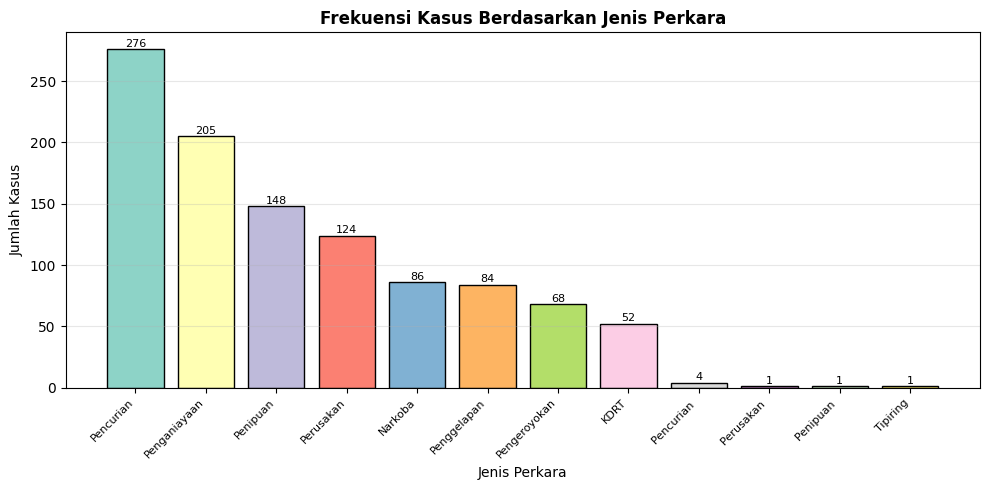

In [9]:
# ============================================
# 1. BAR CHART - Frekuensi Perkara (ukuran kecil)
# ============================================
plt.figure(figsize=(10, 5))
colors = plt.cm.Set3(np.linspace(0, 1, len(perkara_counts)))
bars = plt.bar(perkara_counts.index, perkara_counts.values, color=colors, edgecolor='black')

# Tambahkan nilai di atas bar (perkecil font)
for bar, count in zip(bars, perkara_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom', fontsize=8)

plt.title('Frekuensi Kasus Berdasarkan Jenis Perkara', fontsize=12, fontweight='bold')
plt.xlabel('Jenis Perkara', fontsize=10)
plt.ylabel('Jumlah Kasus', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

## horizontal bar chart Kasus Berdasarkan Jenis Perkara

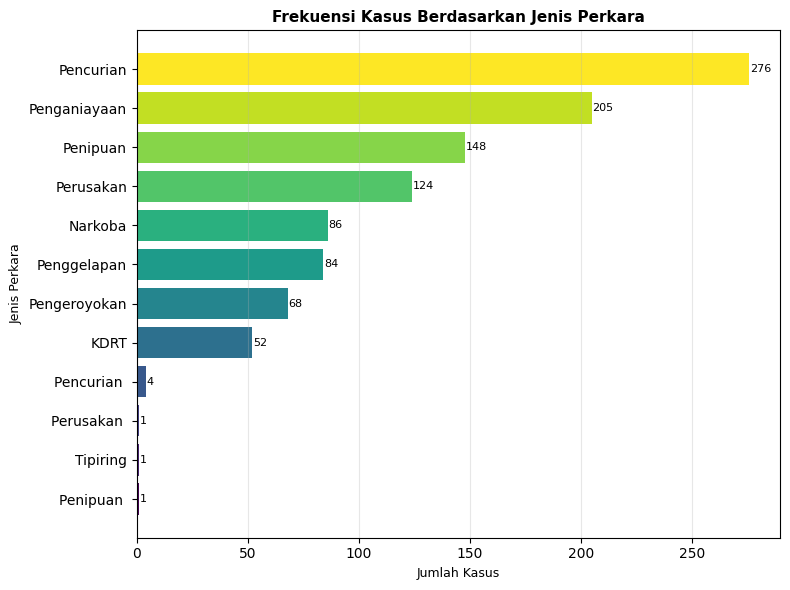

In [10]:
# ============================================
# 2. HORIZONTAL BAR CHART (ukuran kecil, lebih ringkas)
# ============================================
plt.figure(figsize=(8, 6))
perkara_counts_sorted = perkara_counts.sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(perkara_counts_sorted)))
bars = plt.barh(perkara_counts_sorted.index, perkara_counts_sorted.values, color=colors)

# Tambahkan nilai dengan font lebih kecil
for bar, count in zip(bars, perkara_counts_sorted.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             str(count), ha='left', va='center', fontsize=8)

plt.title('Frekuensi Kasus Berdasarkan Jenis Perkara', fontsize=11, fontweight='bold')
plt.xlabel('Jumlah Kasus', fontsize=9)
plt.ylabel('Jenis Perkara', fontsize=9)
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


## pie chart Jenis Perkara

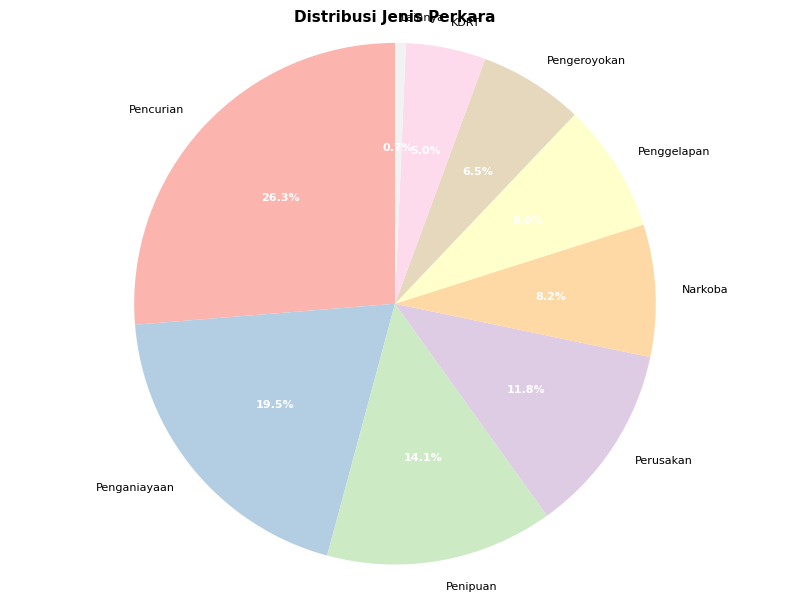

In [11]:
# ============================================
# 3. PIE CHART - Distribusi Perkara (ukuran kecil)
# ============================================
# Ambil top 8 perkara, sisanya digabung menjadi 'Lainnya'
top_n = 8
top_perkara = perkara_counts.head(top_n)
others_count = perkara_counts[top_n:].sum()
if others_count > 0:
    top_perkara['Lainnya'] = others_count

colors = plt.cm.Pastel1(np.linspace(0, 1, len(top_perkara)))
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(top_perkara.values, 
                                     labels=top_perkara.index, 
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 8})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title(f'Distribusi Jenis Perkara', fontsize=11, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


## RINGKASAN STATISTIK PERKARA

In [12]:

# ============================================
# 4. RINGKASAN STATISTIK
# ============================================
print("\n" + "="*60)
print("RINGKASAN STATISTIK PERKARA")
print("="*60)

print(f"\n📊 TOP 5 PERKARA TERBANYAK:")
for i, (perkara, count) in enumerate(perkara_counts.head(5).items(), 1):
    print(f"  {i}. {perkara}: {count} kasus ({perkara_percent[perkara]:.1f}%)")

print(f"\n📊 BOTTOM 3 PERKARA TERSEDIKIT:")
for i, (perkara, count) in enumerate(perkara_counts.tail(3).items(), 1):
    print(f"  {i}. {perkara}: {count} kasus ({perkara_percent[perkara]:.1f}%)")

# Hitung rata-rata dan median
print(f"\n📈 STATISTIK:")
print(f"  Rata-rata kasus per jenis perkara: {perkara_counts.mean():.1f}")
print(f"  Median kasus per jenis perkara: {perkara_counts.median():.1f}")
print(f"  Total jenis perkara: {len(perkara_counts)}")

print("\n" + "="*60)
print("ANALISIS SELESAI")
print("="*60)


RINGKASAN STATISTIK PERKARA

📊 TOP 5 PERKARA TERBANYAK:
  1. Pencurian: 276 kasus (26.3%)
  2. Penganiayaan: 205 kasus (19.5%)
  3. Penipuan: 148 kasus (14.1%)
  4. Perusakan: 124 kasus (11.8%)
  5. Narkoba: 86 kasus (8.2%)

📊 BOTTOM 3 PERKARA TERSEDIKIT:
  1. Perusakan : 1 kasus (0.1%)
  2. Penipuan : 1 kasus (0.1%)
  3. Tipiring: 1 kasus (0.1%)

📈 STATISTIK:
  Rata-rata kasus per jenis perkara: 87.5
  Median kasus per jenis perkara: 76.0
  Total jenis perkara: 12

ANALISIS SELESAI


# 4.1 MEMBERSIHKAN DAN STANDARISASI KATEGORI PERKARA

In [13]:
print("="*80)
print("MEMBERSIHKAN DAN STANDARISASI KATEGORI PERKARA")
print("="*80)

# Tampilkan semua nilai unik PERKARA sebelum dibersihkan
print("\n=== NILAI UNIK PERKARA SEBELUM PEMBERSIHAN ===")
print(df['PERKARA'].unique())
print(f"\nJumlah nilai unik: {df['PERKARA'].nunique()}")

# Fungsi untuk membersihkan dan standarisasi nama perkara
def clean_perkara(value):
    if pd.isna(value):
        return value
    
    # Konversi ke string dan hapus spasi berlebih
    value = str(value).strip()
    
    # Standarisasi nama perkara
    perkara_mapping = {
        'Pencurian': 'Pencurian',
        'pencurian': 'Pencurian',
        'PENCURIAN': 'Pencurian',
        'Penganiayaan': 'Penganiayaan',
        'penganiayaan': 'Penganiayaan',
        'PENGANIAYAAN': 'Penganiayaan',
        'Penipuan': 'Penipuan',
        'penipuan': 'Penipuan',
        'PENIPUAN': 'Penipuan',
        'Perusakan': 'Perusakan',
        'perusakan': 'Perusakan',
        'PERUSAKAN': 'Perusakan',
        'Narkoba': 'Narkoba',
        'narkoba': 'Narkoba',
        'NARKOBA': 'Narkoba',
        'Penggelapan': 'Penggelapan',
        'penggelapan': 'Penggelapan',
        'PENGGELAPAN': 'Penggelapan',
        'Pengeroyokan': 'Pengeroyokan',
        'pengeroyokan': 'Pengeroyokan',
        'PENGEROYOKAN': 'Pengeroyokan',
        'KDRT': 'KDRT',
        'kdrt': 'KDRT',
        'Tipiring': 'Tipiring',
        'tipiring': 'Tipiring',
        'TIPIRING': 'Tipiring',
        'Pencurian ': 'Pencurian',  # ada spasi di akhir
        ' Pencurian': 'Pencurian',  # ada spasi di awal
        'Perusakan ': 'Perusakan',
        'Penipuan ': 'Penipuan',
    }
    
    # Cek apakah value ada di mapping
    if value in perkara_mapping:
        return perkara_mapping[value]
    
    # Coba cek dengan ignore case
    value_lower = value.lower()
    for key, mapped in perkara_mapping.items():
        if key.lower() == value_lower:
            return mapped
    
    return value

# Terapkan pembersihan
df['PERKARA'] = df['PERKARA'].apply(clean_perkara)

# Tampilkan nilai unik setelah dibersihkan
print("\n=== NILAI UNIK PERKARA SETELAH PEMBERSIHAN ===")
print(df['PERKARA'].unique())
print(f"\nJumlah nilai unik: {df['PERKARA'].nunique()}")

# Hitung frekuensi setelah dibersihkan
perkara_counts = df['PERKARA'].value_counts()
perkara_percent = df['PERKARA'].value_counts(normalize=True) * 100

print("\n=== FREKUENSI PERKARA (SETELAH DIBERSIHKAN) ===")
print(perkara_counts)

MEMBERSIHKAN DAN STANDARISASI KATEGORI PERKARA

=== NILAI UNIK PERKARA SEBELUM PEMBERSIHAN ===
['Penganiayaan' 'Pencurian' 'Narkoba' 'Penggelapan' 'Perusakan' 'Penipuan'
 'Pengeroyokan' 'KDRT' 'Perusakan ' 'Pencurian ' 'Penipuan ' 'Tipiring']

Jumlah nilai unik: 12

=== NILAI UNIK PERKARA SETELAH PEMBERSIHAN ===
['Penganiayaan' 'Pencurian' 'Narkoba' 'Penggelapan' 'Perusakan' 'Penipuan'
 'Pengeroyokan' 'KDRT' 'Tipiring']

Jumlah nilai unik: 9

=== FREKUENSI PERKARA (SETELAH DIBERSIHKAN) ===
PERKARA
Pencurian       280
Penganiayaan    205
Penipuan        149
Perusakan       125
Narkoba          86
Penggelapan      84
Pengeroyokan     68
KDRT             52
Tipiring          1
Name: count, dtype: int64


## AMBIL 5 KATEGORI PERKARA "pencurian", "penganiayaan", "penipuan", "narkoba", "perusakan"

In [14]:
# ============================================
# ambil kategori perkara yang diinginkan untuk analisis lebih lanjut
# ============================================

df = df[df['PERKARA'].isin(['Pencurian', 'Penganiayaan', 'Penipuan', 'Perusakan', 'Narkoba'])].copy()

perkara_counts = df['PERKARA'].value_counts()
perkara_percent = df['PERKARA'].value_counts(normalize=True) * 100

print(f"Sisa data setelah filter: {len(df)} baris")
print(f"Jumlah jenis perkara setelah filter: {len(perkara_counts)}")

Sisa data setelah filter: 845 baris
Jumlah jenis perkara setelah filter: 5


## GRAFIK BAR CHART SETELAH PEMBERSIHAN

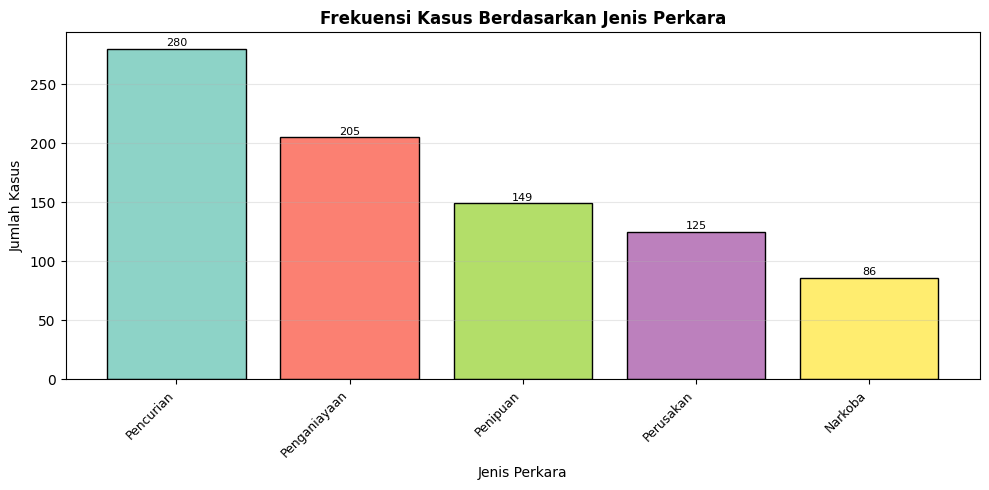

In [15]:
# ============================================
# GRAFIK SETELAH PEMBERSIHAN
# ============================================

# 1. BAR CHART
plt.figure(figsize=(10, 5))
colors = plt.cm.Set3(np.linspace(0, 1, len(perkara_counts)))
bars = plt.bar(perkara_counts.index, perkara_counts.values, color=colors, edgecolor='black')

for bar, count in zip(bars, perkara_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom', fontsize=8)

plt.title('Frekuensi Kasus Berdasarkan Jenis Perkara', fontsize=12, fontweight='bold')
plt.xlabel('Jenis Perkara', fontsize=10)
plt.ylabel('Jumlah Kasus', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()


## GRAFIK HORIZONTAL BAR CHART SETELAH PEMBERSIHAN

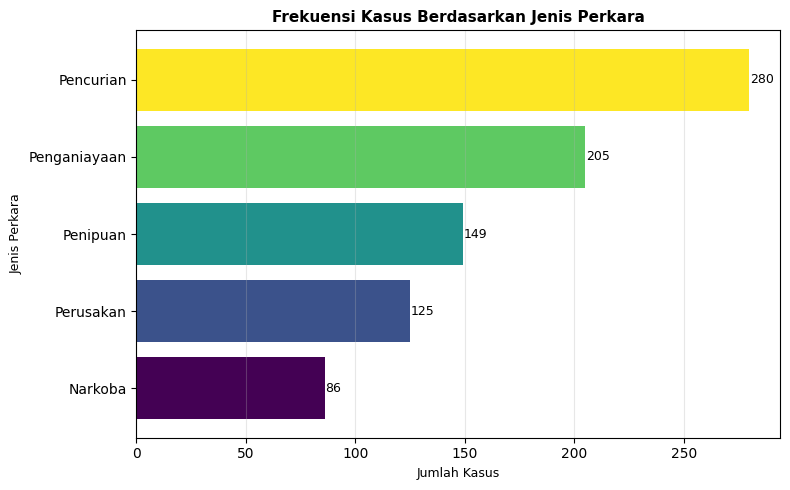

In [16]:

# 2. HORIZONTAL BAR CHART
plt.figure(figsize=(8, 5))
perkara_counts_sorted = perkara_counts.sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(perkara_counts_sorted)))
bars = plt.barh(perkara_counts_sorted.index, perkara_counts_sorted.values, color=colors)

for bar, count in zip(bars, perkara_counts_sorted.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             str(count), ha='left', va='center', fontsize=9)

plt.title('Frekuensi Kasus Berdasarkan Jenis Perkara', fontsize=11, fontweight='bold')
plt.xlabel('Jumlah Kasus', fontsize=9)
plt.ylabel('Jenis Perkara', fontsize=9)
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


## GRAFIK PIE CHART SETELAH PEMBERSIHAN

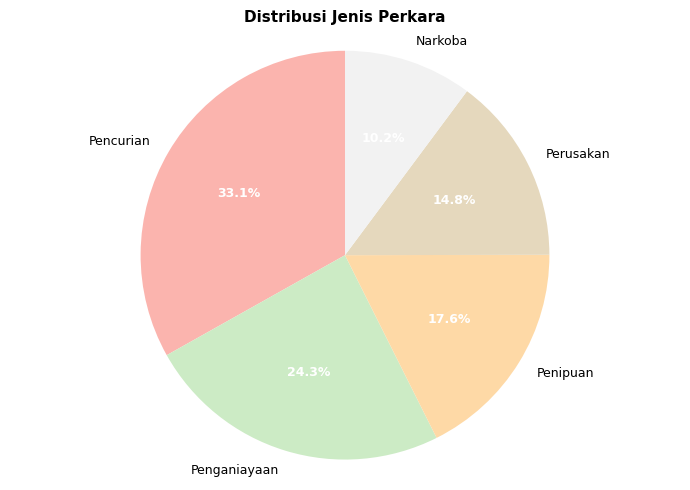

In [17]:

# 3. PIE CHART
plt.figure(figsize=(7, 5))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(perkara_counts)))
wedges, texts, autotexts = plt.pie(perkara_counts.values, 
                                     labels=perkara_counts.index, 
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribusi Jenis Perkara', fontsize=11, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


## RINGKASAN STATISTIK PERKARA

In [18]:
# ============================================
# RINGKASAN STATISTIK
# ============================================
print("\n" + "="*60)
print("RINGKASAN STATISTIK PERKARA (SETELAH PEMBERSIHAN)")
print("="*60)

print(f"\n📊 TOP 3 PERKARA TERBANYAK:")
for i, (perkara, count) in enumerate(perkara_counts.head(3).items(), 1):
    print(f"  {i}. {perkara}: {count} kasus ({perkara_percent[perkara]:.1f}%)")

print(f"\n📊 BOTTOM PERKARA:")
for i, (perkara, count) in enumerate(perkara_counts.tail(2).items(), 1):
    print(f"  {i}. {perkara}: {count} kasus ({perkara_percent[perkara]:.1f}%)")



print("\n" + "="*60)
print("PEMBERSIHAN DAN ANALISIS SELESAI")
print("="*60)


RINGKASAN STATISTIK PERKARA (SETELAH PEMBERSIHAN)

📊 TOP 3 PERKARA TERBANYAK:
  1. Pencurian: 280 kasus (33.1%)
  2. Penganiayaan: 205 kasus (24.3%)
  3. Penipuan: 149 kasus (17.6%)

📊 BOTTOM PERKARA:
  1. Perusakan: 125 kasus (14.8%)
  2. Narkoba: 86 kasus (10.2%)

PEMBERSIHAN DAN ANALISIS SELESAI


# 5. Analisa TKP Kasus

In [19]:
df["TKP"].head()

0    Dusun Melati, Sungai Purun Kecil, Kec. Sungai ...
1    Gg. Usaha RT 20/RW 09, Sungai Batang, Kec. Sun...
2    Jl. Raya Nusapati RT 09/RW 05, Sungai Purun Ke...
3    Dusun Sejahtera, Sungai Batang, Kec. Sungai Pi...
4    Gg. Famili, Desa/Kel. Peniraman, Kec. Sungai P...
Name: TKP, dtype: object

## ekstrak nama desa dari data

In [20]:
def extract_desa(tkp):
    if pd.isna(tkp):
        return 'Tidak diketahui'
    tkp = str(tkp).lower()
    
    # Urutan prioritas (spesifik dulu)
    if 'sungai purun kecil' in tkp:
        return 'Sungai Purun Kecil'
    if 'sungai purun besar' in tkp:
        return 'Sungai Purun Besar'
    if 'sungai bakau besar laut' in tkp:
        return 'Sungai Bakau Besar Laut'
    if 'sungai bakau besar darat' in tkp:
        return 'Sungai Bakau Besar Darat'
    if 'peniraman' in tkp:
        return 'Peniraman'
    if 'galang' in tkp:
        return 'Galang'
    if 'nusapati' in tkp:
        return 'Nusapati'
    if 'sungai batang' in tkp or 'sui batang' in tkp:
        return 'Sungai Batang'
    if 'sungai rasau' in tkp or 'sui rasau' in tkp:
        return 'Sungai Rasau'
    if 'sungai purun' in tkp or 'sui purun' in tkp:
        return 'Sungai Purun'
    if 'sungai bakau' in tkp or 'sui bakau' in tkp:
        return 'Sungai Bakau'
    if 'sungai pinyuh' in tkp or 'sui pinyuh' in tkp:
        return 'Sungai Pinyuh'
    
    return 'Lainnya'

# Terapkan ekstraksi
df['DESA'] = df['TKP'].apply(extract_desa)

print("="*60)
print("✅ EKSTRAKSI DESA SELESAI")
print("="*60)

# Tampilkan hasil
print("\n📊 FREKUENSI KASUS PER DESA KESELURUHAN:")
desa_counts = df['DESA'].value_counts()
print(desa_counts)

✅ EKSTRAKSI DESA SELESAI

📊 FREKUENSI KASUS PER DESA KESELURUHAN:
DESA
Peniraman                   136
Sungai Pinyuh               114
Nusapati                     98
Sungai Rasau                 93
Galang                       86
Sungai Batang                86
Sungai Purun Kecil           83
Sungai Bakau Besar Laut      81
Sungai Bakau Besar Darat     32
Sungai Purun Besar           28
Lainnya                       4
Sungai Bakau                  3
Sungai Purun                  1
Name: count, dtype: int64


## grafik horizontal bar chart desa

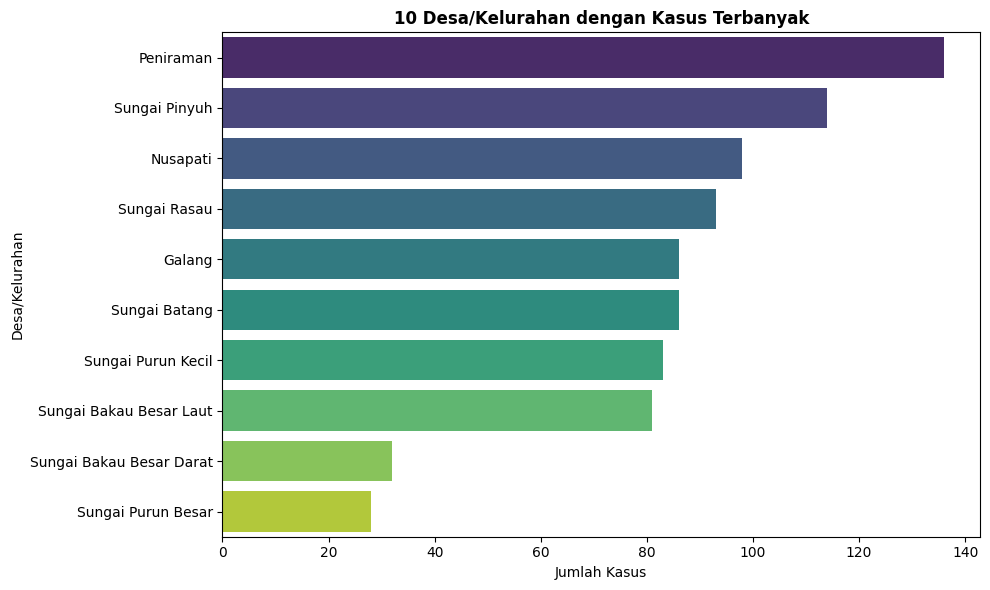


📊 RINGKASAN HASIL:

Total desa yang teridentifikasi: 13
Desa dengan kasus terbanyak: Peniraman (136 kasus)
Desa dengan kasus tersedikit (dalam top 10): Sungai Purun Besar (28 kasus)


In [21]:
# ============================================
# GRAFIK DESA
# ============================================

desa_top10 = desa_counts.head(10)
plt.figure(figsize=(10, 6))
# Buat dataframe terlebih dahulu
df_desa = pd.DataFrame({
    'DESA': desa_top10.index,
    'JUMLAH': desa_top10.values
})
sns.barplot(data=df_desa, y='DESA', x='JUMLAH', hue='DESA', palette='viridis', legend=False)
plt.title('10 Desa/Kelurahan dengan Kasus Terbanyak', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Kasus', fontsize=10)
plt.ylabel('Desa/Kelurahan', fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 RINGKASAN HASIL:")
print("="*60)
print(f"\nTotal desa yang teridentifikasi: {len(desa_counts)}")
print(f"Desa dengan kasus terbanyak: {desa_top10.index[0]} ({desa_top10.values[0]} kasus)")
print(f"Desa dengan kasus tersedikit (dalam top 10): {desa_top10.index[-1]} ({desa_top10.values[-1]} kasus)")

# 6. Analisis kolom proses
## cek data kosong

In [22]:
print("="*70)
print("INSPEKSI AWAL KOLOM PROSES")
print("="*70)

# ============================================
# 1. CEK DATA KOSONG
# ============================================
print("\n📊 1. CEK DATA KOSONG:")
print("-" * 50)
null_count = df['PROSES'].isna().sum()
empty_count = (df['PROSES'] == '').sum()
total_empty = null_count + empty_count

print(f"  - Null (NaN): {null_count} baris")
print(f"  - Empty string: {empty_count} baris")
print(f"  - Total kosong: {total_empty} baris")
print(f"  - Total terisi: {len(df) - total_empty} baris")


INSPEKSI AWAL KOLOM PROSES

📊 1. CEK DATA KOSONG:
--------------------------------------------------
  - Null (NaN): 0 baris
  - Empty string: 0 baris
  - Total kosong: 0 baris
  - Total terisi: 845 baris


## pie chart

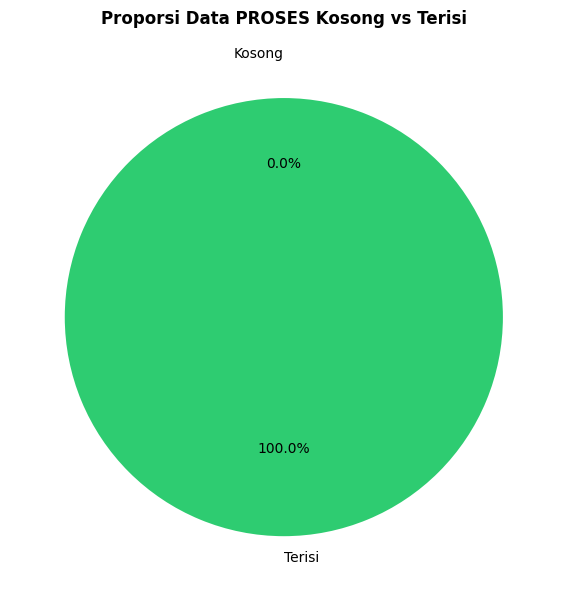

In [23]:
# CHART 1: Pie Chart Data Kosong vs Terisi
plt.figure(figsize=(6, 6))
labels = ['Terisi', 'Kosong']
sizes = [len(df) - total_empty, total_empty]
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, startangle=90)
plt.title('Proporsi Data PROSES Kosong vs Terisi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## sampel data proses 

In [24]:
# ============================================
# 2. TAMPILKAN SAMPEL DATA PROSES (20 baris)
# ============================================
print("\n📊 2. SAMPEL DATA PROSES (20 baris pertama):")
print("-" * 50)
sample_data = []
for i in range(min(20, len(df))):
    proses_value = df['PROSES'].iloc[i]
    if pd.isna(proses_value) or proses_value == '':
        display_val = "[KOSONG/BLANK]"
    else:
        display_val = proses_value
    sample_data.append(display_val)
    print(f"  {i+1:2d}. {display_val}")


📊 2. SAMPEL DATA PROSES (20 baris pertama):
--------------------------------------------------
   1. Sidik
   2. Sidik
   3. Sidik
   4. Dalam Lidik
   5. Sidik
   6. Sidik
   7. Sidik
   8. Sidik
   9. Sidik
  10. Sidik
  11. Sidik
  12. Sidik
  13. Dalam Lidik
  14. Sidik
  15. Sidik
  16. Sidik
  17. Sidik
  18. Sidik
  19. Dalam Lidik
  20. Sidik


## nilai unik kolom proses

In [25]:
# ============================================
# 3. NILAI UNIK DI KOLOM PROSES
# ============================================
print("\n📊 3. NILAI UNIK DI KOLOM PROSES:")
print("-" * 50)

# Filter nilai yang tidak kosong
unique_values = df[df['PROSES'].notna() & (df['PROSES'] != '')]['PROSES'].unique()
print(f"  Jumlah nilai unik: {len(unique_values)}")

print("\n  Daftar nilai unik (sorted):")
for i, val in enumerate(sorted(unique_values), 1):
    print(f"    {i:2d}. '{val}'")


📊 3. NILAI UNIK DI KOLOM PROSES:
--------------------------------------------------
  Jumlah nilai unik: 6

  Daftar nilai unik (sorted):
     1. 'Dalam Lidik'
     2. 'LIDIK'
     3. 'Lidik'
     4. 'SIDIK'
     5. 'SP3'
     6. 'Sidik'


## frekuensi nilai kolom proses

In [26]:
# ============================================
# 4. FREKUENSI SETIAP NILAI PROSES (SEBELUM PEMBERSIHAN)
# ============================================
print("\n📊 4. FREKUENSI NILAI PROSES (SEBELUM PEMBERSIHAN):")
print("-" * 50)

proses_counts_before = df['PROSES'].value_counts(dropna=False)
proses_data = []

for proses, count in proses_counts_before.items():
    if pd.isna(proses):
        proses_name = "NaN (Kosong)"
    elif proses == '':
        proses_name = "Empty String"
    else:
        proses_name = f"{proses}"
    percentage = (count / len(df)) * 100
    proses_data.append({'PROSES': proses_name, 'JUMLAH': count, 'PERSEN': percentage})
    print(f"  {proses_name}: {count} kasus ({percentage:.1f}%)")



📊 4. FREKUENSI NILAI PROSES (SEBELUM PEMBERSIHAN):
--------------------------------------------------
  Sidik: 540 kasus (63.9%)
  Dalam Lidik: 189 kasus (22.4%)
  SIDIK: 103 kasus (12.2%)
  Lidik: 7 kasus (0.8%)
  LIDIK: 5 kasus (0.6%)
  SP3: 1 kasus (0.1%)


## bar chart frekuensi nilai kolom proses

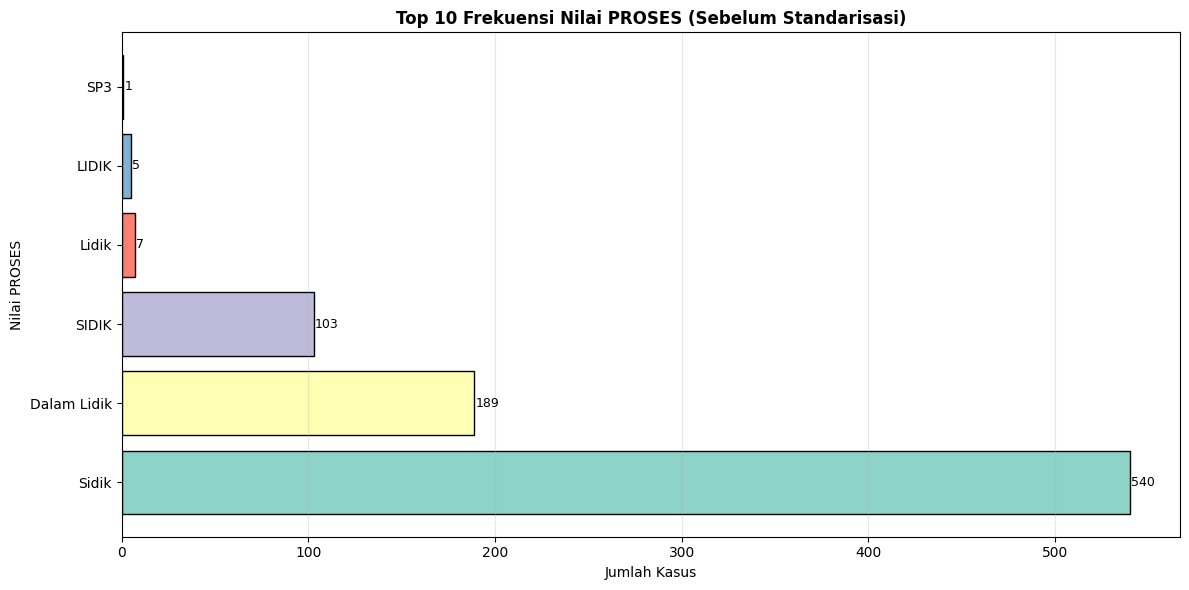

In [27]:
# CHART 2: Bar Chart Frekuensi Nilai PROSES (Top 10)
plt.figure(figsize=(12, 6))
proses_df = pd.DataFrame(proses_data)
proses_df_top10 = proses_df.nlargest(10, 'JUMLAH')

colors = plt.cm.Set3(range(len(proses_df_top10)))
bars = plt.barh(proses_df_top10['PROSES'], proses_df_top10['JUMLAH'], color=colors, edgecolor='black')

for bar, count in zip(bars, proses_df_top10['JUMLAH']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(int(count)), ha='left', va='center', fontsize=9)

plt.title('Top 10 Frekuensi Nilai PROSES (Sebelum Standarisasi)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Kasus', fontsize=10)
plt.ylabel('Nilai PROSES', fontsize=10)
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


## pengecekan duplikasi nilai kolom proses

In [28]:
# ============================================
# 5. CEK DUPLIKASI NILAI (HURUF BESAR/KECIL, SPASI)
# ============================================
print("\n📊 5. CEK DUPLIKASI / VARIASI PENULISAN:")
print("-" * 50)

# Ambil nilai unik yang tidak kosong
unique_nonempty = [v for v in unique_values if v and not pd.isna(v)]

# Kelompokkan berdasarkan lowercase
lowercase_groups = {}
for val in unique_nonempty:
    val_lower = val.lower().strip()
    if val_lower not in lowercase_groups:
        lowercase_groups[val_lower] = []
    lowercase_groups[val_lower].append(val)

duplicate_groups = []
print("  Variasi penulisan yang mungkin perlu digabung:")
for lower_val, variants in lowercase_groups.items():
    if len(variants) > 1:
        duplicate_groups.append({'VARIASI': lower_val, 'JUMLAH_VARIASI': len(variants), 'VARIANTS': variants})
        print(f"\n    '{lower_val}' -> {len(variants)} variasi:")
        for v in variants:
            print(f"      - '{v}'")

if not duplicate_groups:
    print("    Tidak ditemukan duplikasi variasi")



📊 5. CEK DUPLIKASI / VARIASI PENULISAN:
--------------------------------------------------
  Variasi penulisan yang mungkin perlu digabung:

    'sidik' -> 2 variasi:
      - 'Sidik'
      - 'SIDIK'

    'lidik' -> 2 variasi:
      - 'Lidik'
      - 'LIDIK'


## bar chart kelompok terduplikasi

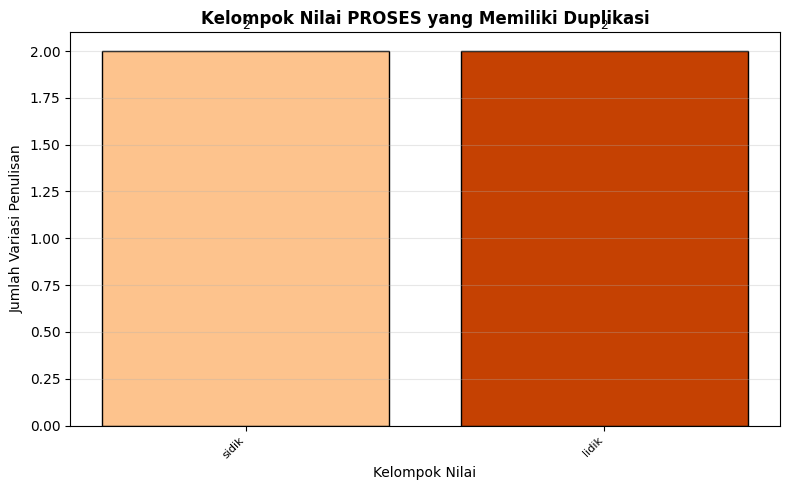

In [29]:
# CHART 3: Bar Chart Jumlah Kelompok Duplikasi
if duplicate_groups:
    plt.figure(figsize=(8, 5))
    dup_df = pd.DataFrame(duplicate_groups)
    colors = plt.cm.Oranges(np.linspace(0.3, 0.8, len(dup_df)))
    bars = plt.bar(range(len(dup_df)), dup_df['JUMLAH_VARIASI'], color=colors, edgecolor='black')
    plt.xticks(range(len(dup_df)), dup_df['VARIASI'], rotation=45, ha='right', fontsize=8)
    plt.title('Kelompok Nilai PROSES yang Memiliki Duplikasi', fontsize=12, fontweight='bold')
    plt.xlabel('Kelompok Nilai', fontsize=10)
    plt.ylabel('Jumlah Variasi Penulisan', fontsize=10)
    
    for bar, count in zip(bars, dup_df['JUMLAH_VARIASI']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


## ringkasan nilai proses

In [30]:
# ============================================
# RINGKASAN INSPEKSI
# ============================================
print("\n" + "="*70)
print("RINGKASAN INSPEKSI AWAL:")
print("="*70)
print(f"  ✓ Total baris: {len(df)}")
print(f"  ✓ Kolom PROSES kosong: {total_empty} baris ({total_empty/len(df)*100:.1f}%)")
print(f"  ✓ Nilai unik PROSES: {len(unique_values)}")
print(f"  ⚠ Potensi duplikasi: {len(duplicate_groups)} kelompok")



RINGKASAN INSPEKSI AWAL:
  ✓ Total baris: 845
  ✓ Kolom PROSES kosong: 0 baris (0.0%)
  ✓ Nilai unik PROSES: 6
  ⚠ Potensi duplikasi: 2 kelompok


## ringkasan chart nilai kolom proses

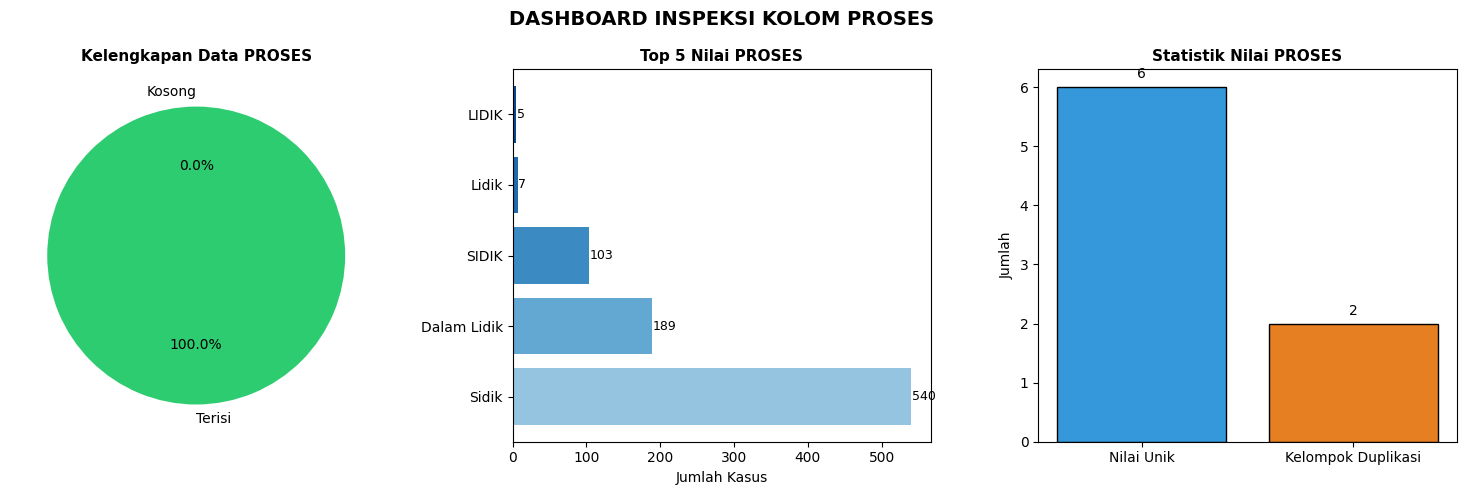


INSPEKSI SELESAI


In [31]:
# CHART 5: Ringkasan Dashboard
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: Data Kosong vs Terisi
labels = ['Terisi', 'Kosong']
sizes = [len(df) - total_empty, total_empty]
colors_donut = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_donut, startangle=90)
axes[0].set_title('Kelengkapan Data PROSES', fontsize=11, fontweight='bold')

# Subplot 2: Top 5 Nilai PROSES
top5_proses_values = proses_counts_before.head(5)
axes[1].barh(range(len(top5_proses_values)), top5_proses_values.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top5_proses_values))))
axes[1].set_yticks(range(len(top5_proses_values)))
axes[1].set_yticklabels([str(k)[:25] for k in top5_proses_values.index])
axes[1].set_xlabel('Jumlah Kasus')
axes[1].set_title('Top 5 Nilai PROSES', fontsize=11, fontweight='bold')
for i, v in enumerate(top5_proses_values.values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)

# Subplot 3: Statistik Nilai Unik
stats_labels = ['Nilai Unik', 'Kelompok Duplikasi']
stats_values = [len(unique_values), len(duplicate_groups)]
colors_stats = ['#3498db', '#e67e22']
axes[2].bar(stats_labels, stats_values, color=colors_stats, edgecolor='black')
axes[2].set_ylabel('Jumlah')
axes[2].set_title('Statistik Nilai PROSES', fontsize=11, fontweight='bold')
for i, v in enumerate(stats_values):
    axes[2].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=10)

plt.suptitle('DASHBOARD INSPEKSI KOLOM PROSES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INSPEKSI SELESAI")
print("="*70)

# 6.1 PEMBERSIHAN DAN STANDARISASI KOLOM PROSES

In [32]:
print("="*70)
print("PEMBERSIHAN DAN STANDARISASI KOLOM PROSES")
print("="*70)

# Tampilkan nilai unik sebelum pembersihan
print("\n📊 NILAI UNIK SEBELUM PEMBERSIHAN:")
unique_before = df[df['PROSES'].notna() & (df['PROSES'] != '')]['PROSES'].unique()
print(f"   Jumlah: {len(unique_before)}")
for i, val in enumerate(sorted(unique_before), 1):
    print(f"   {i:2d}. '{val}'")

PEMBERSIHAN DAN STANDARISASI KOLOM PROSES

📊 NILAI UNIK SEBELUM PEMBERSIHAN:
   Jumlah: 6
    1. 'Dalam Lidik'
    2. 'LIDIK'
    3. 'Lidik'
    4. 'SIDIK'
    5. 'SP3'
    6. 'Sidik'


## BUAT FUNGSI NORMALISASI

In [33]:
def standardize_proses(x):
    if pd.isna(x):
        return x
    
    x = x.lower().strip()
    
    if x == "sidik":
        return "SIDIK"
    elif x == "lidik":
        return "LIDIK"
    elif x == "dalam lidik":
        return "DALAM LIDIK"
    elif x == "sp3":
        return "SP3"
    
    return x.upper()

## TERAPKAN KE DATAFRAME

In [34]:
df['PROSES_STD'] = df['PROSES'].apply(standardize_proses)

## HASIL SETELAH STANDARISASI

In [35]:
# ============================================
# HASIL SETELAH STANDARISASI
# ============================================
print("\n📊 NILAI UNIK SETELAH STANDARISASI:")
unique_after = df['PROSES_STD'].unique()
print(f"   Jumlah: {len(unique_after)}")
for i, val in enumerate(sorted(unique_after), 1):
    count = len(df[df['PROSES_STD'] == val])
    print(f"   {i:2d}. '{val}' ({count} kasus)")



📊 NILAI UNIK SETELAH STANDARISASI:
   Jumlah: 4
    1. 'DALAM LIDIK' (189 kasus)
    2. 'LIDIK' (12 kasus)
    3. 'SIDIK' (643 kasus)
    4. 'SP3' (1 kasus)


In [36]:
# ============================================
# PERBANDINGAN SEBELUM VS SESUDAH
# ============================================
print("\n📊 PERBANDINGAN STANDARISASI:")
print("-" * 60)

comparison_data = []
for old_val in sorted(unique_before):
    old_count = len(df[df['PROSES'] == old_val])
    new_val = standardize_proses(old_val)
    new_count = len(df[df['PROSES_STD'] == new_val])
    comparison_data.append({
        'Sebelum': old_val,
        'Sesudah': new_val,
        'Jumlah': old_count
    })
    print(f"   '{old_val}' ({old_count} kasus) → '{new_val}'")


📊 PERBANDINGAN STANDARISASI:
------------------------------------------------------------
   'Dalam Lidik' (189 kasus) → 'DALAM LIDIK'
   'LIDIK' (5 kasus) → 'LIDIK'
   'Lidik' (7 kasus) → 'LIDIK'
   'SIDIK' (103 kasus) → 'SIDIK'
   'SP3' (1 kasus) → 'SP3'
   'Sidik' (540 kasus) → 'SIDIK'


## FREKUENSI FINAL KOLOM PROSES

In [37]:
# ============================================
# FREKUENSI FINAL
# ============================================
print("\n📊 FREKUENSI KET FINAL (SETELAH STANDARISASI):")
print("-" * 60)

proses_counts = df['PROSES_STD'].value_counts()
proses_percent = df['PROSES_STD'].value_counts(normalize=True) * 100

for proses, count in proses_counts.items():
    bar = "█" * int(count / 10)
    print(f"   {proses:30} : {count:4} kasus ({proses_percent[proses]:5.1f}%) {bar}")


📊 FREKUENSI KET FINAL (SETELAH STANDARISASI):
------------------------------------------------------------
   SIDIK                          :  643 kasus ( 76.1%) ████████████████████████████████████████████████████████████████
   DALAM LIDIK                    :  189 kasus ( 22.4%) ██████████████████
   LIDIK                          :   12 kasus (  1.4%) █
   SP3                            :    1 kasus (  0.1%) 


# bar chart

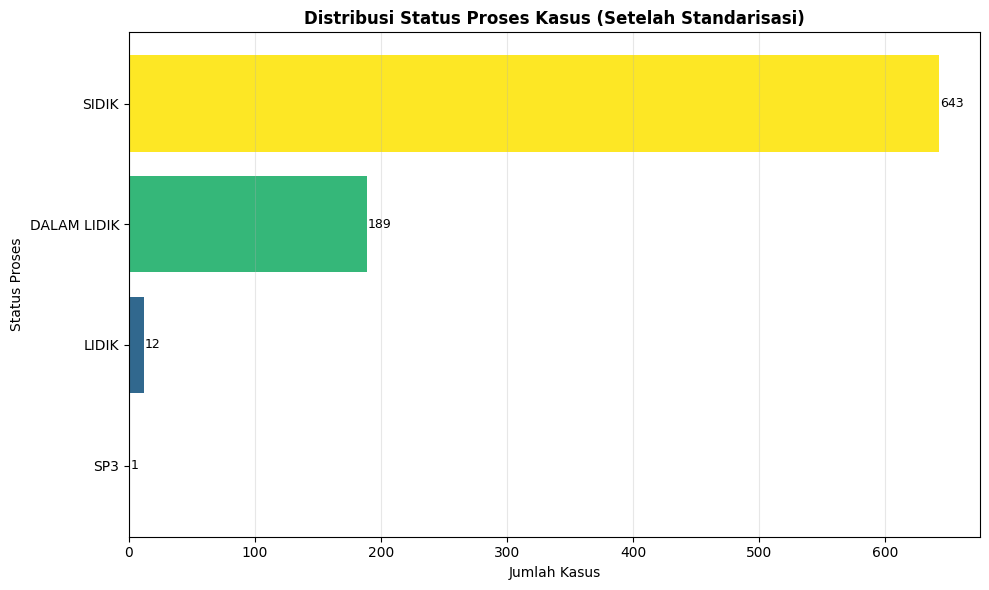

In [38]:
# ============================================
# GRAFIK DISTRIBUSI PROSES
# ============================================

# 1. Horizontal Bar Chart
plt.figure(figsize=(10, 6))
proses_counts_sorted = proses_counts.sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(proses_counts_sorted)))
bars = plt.barh(proses_counts_sorted.index, proses_counts_sorted.values, color=colors)

for bar, count in zip(bars, proses_counts_sorted.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(count), ha='left', va='center', fontsize=9)

plt.title('Distribusi Status Proses Kasus (Setelah Standarisasi)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Kasus', fontsize=10)
plt.ylabel('Status Proses', fontsize=10)
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


## Pie Chart KOLOM PROSES

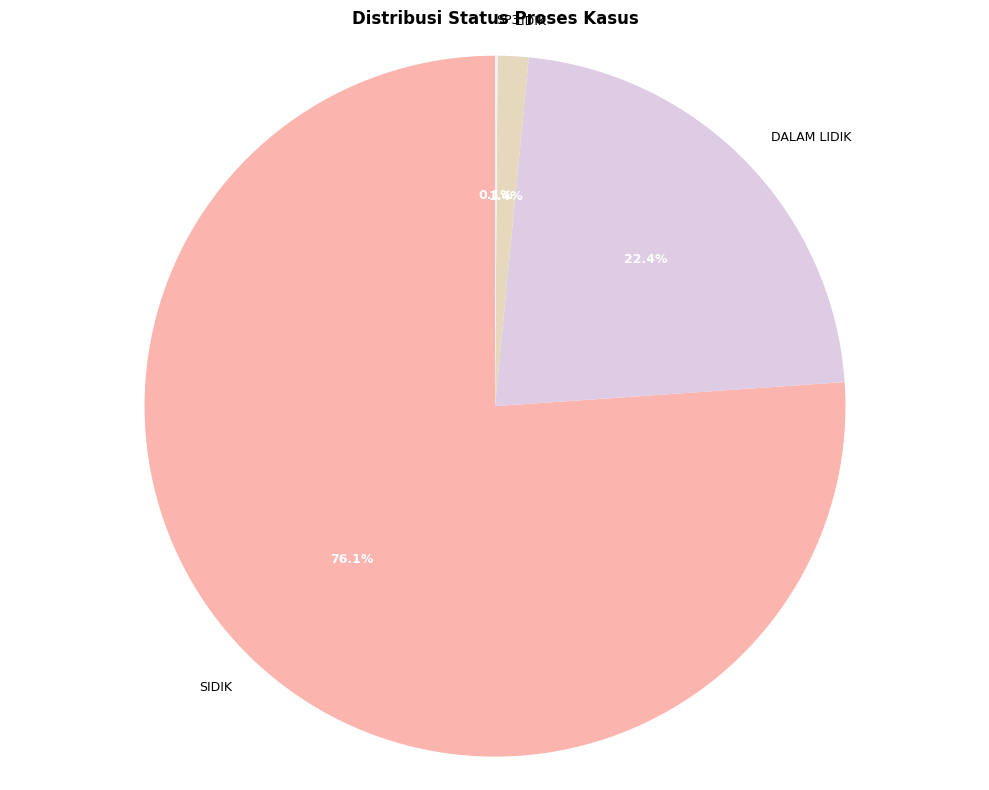

In [39]:

# 2. Pie Chart
plt.figure(figsize=(10, 8))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(proses_counts)))
wedges, texts, autotexts = plt.pie(proses_counts.values, 
                                     labels=proses_counts.index, 
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribusi Status Proses Kasus', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## RINGKASAN AKHIR KOLOM PROSES

In [40]:
# ============================================
# RINGKASAN AKHIR
# ============================================
print("\n" + "="*70)
print("RINGKASAN PEMBERSIHAN KOLOM PROSES")
print("="*70)

print(f"\n✅ Sebelum standarisasi: {len(unique_before)} nilai unik")
print(f"✅ Setelah standarisasi: {len(proses_counts)} nilai unik")
print(f"✅ Pengurangan: {len(unique_before) - len(proses_counts)} nilai unik (digabung)")

print("\n📊 HASIL AKHIR STATUS PROSES:")
for proses, count in proses_counts.items():
    bar = "█" * int(count / 15)
    print(f"   {proses:30} : {count:4} kasus ({proses_percent[proses]:5.1f}%)")

# Hapus kolom PROSES asli dan ganti dengan PROSES_STD
df.drop(columns=['PROSES'], inplace=True)
df.rename(columns={'PROSES_STD': 'PROSES'}, inplace=True)

print("\n" + "="*70)
print("PEMBERSIHAN SELESAI")
print("="*70)


RINGKASAN PEMBERSIHAN KOLOM PROSES

✅ Sebelum standarisasi: 6 nilai unik
✅ Setelah standarisasi: 4 nilai unik
✅ Pengurangan: 2 nilai unik (digabung)

📊 HASIL AKHIR STATUS PROSES:
   SIDIK                          :  643 kasus ( 76.1%)
   DALAM LIDIK                    :  189 kasus ( 22.4%)
   LIDIK                          :   12 kasus (  1.4%)
   SP3                            :    1 kasus (  0.1%)

PEMBERSIHAN SELESAI


# 7. Analisan KET (KETERANGAN)

In [41]:
print("="*70)
print("INSPEKSI AWAL KOLOM KET (KETERANGAN)")
print("="*70)

# ============================================
# 1. CEK DATA KOSONG
# ============================================
print("\n📊 1. CEK DATA KOSONG:")
print("-" * 50)
null_count = df['KET'].isna().sum()
empty_count = (df['KET'] == '').sum()
total_empty = null_count + empty_count

print(f"  - Null (NaN): {null_count} baris")
print(f"  - Empty string: {empty_count} baris")
print(f"  - Total kosong: {total_empty} baris")
print(f"  - Total terisi: {len(df) - total_empty} baris")


INSPEKSI AWAL KOLOM KET (KETERANGAN)

📊 1. CEK DATA KOSONG:
--------------------------------------------------
  - Null (NaN): 0 baris
  - Empty string: 0 baris
  - Total kosong: 0 baris
  - Total terisi: 845 baris


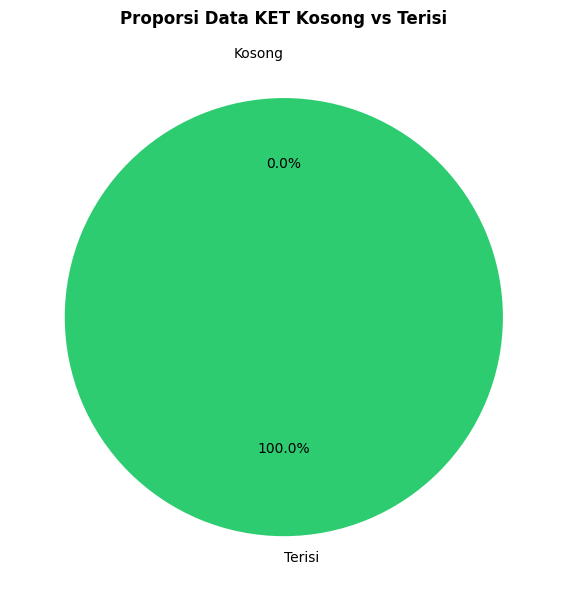

In [42]:
# CHART 1: Pie Chart Data Kosong vs Terisi
plt.figure(figsize=(6, 6))
labels = ['Terisi', 'Kosong']
sizes = [len(df) - total_empty, total_empty]
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, startangle=90)
plt.title('Proporsi Data KET Kosong vs Terisi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## SAMPEL DATA KET

In [43]:
# ============================================
# 2. TAMPILKAN SAMPEL DATA KET (20 baris)
# ============================================
print("\n📊 2. SAMPEL DATA KET (20 baris pertama):")
print("-" * 50)
sample_data = []
for i in range(min(20, len(df))):
    ket_value = df['KET'].iloc[i]
    if pd.isna(ket_value) or ket_value == '':
        display_val = "[KOSONG/BLANK]"
    else:
        display_val = ket_value
    sample_data.append(display_val)
    print(f"  {i+1:2d}. {display_val}")


📊 2. SAMPEL DATA KET (20 baris pertama):
--------------------------------------------------
   1. Tipiring Sidang PN
   2. P. 21 Tahap II
   3. Tahap I
   4. Lidik
   5. P. 21 Tahap II
   6. Tahap I
   7. Tahap I
   8. Tahap I
   9. P. 21 Tahap II
  10. P. 21 Tahap II
  11. P. 21 Tahap II
  12. Tahap I
  13. Lidik
  14. Tipiring Sidang PN
  15. Tahap I
  16. P. 21 Tahap II
  17. P. 21 Tahap II
  18. Tipiring Sidang PN
  19. Lidik
  20. Tahap I


## NILAI UNIK DI KOLOM KET

In [44]:
# ============================================
# 3. NILAI UNIK DI KOLOM KET
# ============================================
print("\n📊 3. NILAI UNIK DI KOLOM KET:")
print("-" * 50)

# Filter nilai yang tidak kosong
unique_values = df[df['KET'].notna() & (df['KET'] != '')]['KET'].unique()
print(f"  Jumlah nilai unik: {len(unique_values)}")

print("\n  Daftar nilai unik (sorted):")
for i, val in enumerate(sorted(unique_values), 1):
    print(f"    {i:2d}. '{val}'")


📊 3. NILAI UNIK DI KOLOM KET:
--------------------------------------------------
  Jumlah nilai unik: 16

  Daftar nilai unik (sorted):
     1. 'Dilimpahkan ke Polres'
     2. 'LIDIK'
     3. 'LIMPAH POLRES'
     4. 'Lidik'
     5. 'Limpah JPU'
     6. 'Limpah ke JPU'
     7. 'P. 21 Tahap II'
     8. 'P.21 Tahap II'
     9. 'Proses Penyelidikan'
    10. 'Proses Penyidikan'
    11. 'Restorative Justice'
    12. 'TAHAP I'
    13. 'Tahap I'
    14. 'Tahap II '
    15. 'Tahap II tgl 23 April 2022'
    16. 'Tipiring Sidang PN'


## FREKUENSI SETIAP NILAI KET

In [45]:
# ============================================
# 4. FREKUENSI SETIAP NILAI KET (SEBELUM PEMBERSIHAN)
# ============================================
print("\n📊 4. FREKUENSI NILAI KET (SEBELUM PEMBERSIHAN):")
print("-" * 50)

ket_counts_before = df['KET'].value_counts(dropna=False)
ket_data = []

for ket, count in ket_counts_before.items():
    if pd.isna(ket):
        ket_name = "NaN (Kosong)"
    elif ket == '':
        ket_name = "Empty String"
    else:
        ket_name = f"{ket}"
    percentage = (count / len(df)) * 100
    ket_data.append({'KET': ket_name, 'JUMLAH': count, 'PERSEN': percentage})
    print(f"  {ket_name}: {count} kasus ({percentage:.1f}%)")



📊 4. FREKUENSI NILAI KET (SEBELUM PEMBERSIHAN):
--------------------------------------------------
  P. 21 Tahap II: 269 kasus (31.8%)
  Lidik: 188 kasus (22.2%)
  Tahap I: 175 kasus (20.7%)
  P.21 Tahap II: 89 kasus (10.5%)
  Tipiring Sidang PN: 76 kasus (9.0%)
  Limpah JPU: 15 kasus (1.8%)
  TAHAP I: 15 kasus (1.8%)
  Dilimpahkan ke Polres: 6 kasus (0.7%)
  LIDIK: 4 kasus (0.5%)
  Tahap II : 2 kasus (0.2%)
  Tahap II tgl 23 April 2022: 1 kasus (0.1%)
  Proses Penyidikan: 1 kasus (0.1%)
  Limpah ke JPU: 1 kasus (0.1%)
  Proses Penyelidikan: 1 kasus (0.1%)
  Restorative Justice: 1 kasus (0.1%)
  LIMPAH POLRES: 1 kasus (0.1%)


## Bar Chart Frekuensi Nilai KET

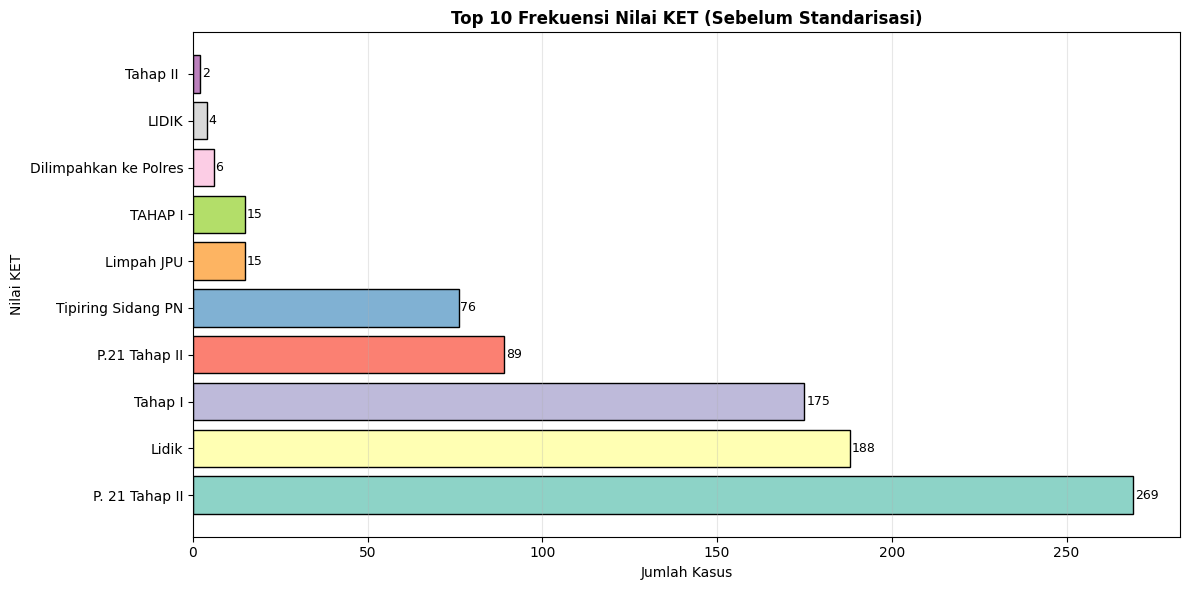

In [46]:
# CHART 2: Bar Chart Frekuensi Nilai KET (Top 10)
plt.figure(figsize=(12, 6))
ket_df = pd.DataFrame(ket_data)
ket_df_top10 = ket_df.nlargest(10, 'JUMLAH')

colors = plt.cm.Set3(range(len(ket_df_top10)))
bars = plt.barh(ket_df_top10['KET'], ket_df_top10['JUMLAH'], color=colors, edgecolor='black')

for bar, count in zip(bars, ket_df_top10['JUMLAH']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(int(count)), ha='left', va='center', fontsize=9)

plt.title('Top 10 Frekuensi Nilai KET (Sebelum Standarisasi)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Kasus', fontsize=10)
plt.ylabel('Nilai KET', fontsize=10)
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


## CEK DUPLIKASI NILAI

In [47]:
# ============================================
# 5. CEK DUPLIKASI NILAI (HURUF BESAR/KECIL, SPASI)
# ============================================
print("\n📊 5. CEK DUPLIKASI / VARIASI PENULISAN:")
print("-" * 50)

# Ambil nilai unik yang tidak kosong
unique_nonempty = [v for v in unique_values if v and not pd.isna(v)]

# Kelompokkan berdasarkan lowercase
lowercase_groups = {}
for val in unique_nonempty:
    val_lower = val.lower().strip()
    if val_lower not in lowercase_groups:
        lowercase_groups[val_lower] = []
    lowercase_groups[val_lower].append(val)

duplicate_groups = []
print("  Variasi penulisan yang mungkin perlu digabung:")
for lower_val, variants in lowercase_groups.items():
    if len(variants) > 1:
        duplicate_groups.append({'VARIASI': lower_val, 'JUMLAH_VARIASI': len(variants), 'VARIANTS': variants})
        print(f"\n    '{lower_val}' -> {len(variants)} variasi:")
        for v in variants:
            print(f"      - '{v}'")

if not duplicate_groups:
    print("    Tidak ditemukan duplikasi variasi")



📊 5. CEK DUPLIKASI / VARIASI PENULISAN:
--------------------------------------------------
  Variasi penulisan yang mungkin perlu digabung:

    'tahap i' -> 2 variasi:
      - 'Tahap I'
      - 'TAHAP I'

    'lidik' -> 2 variasi:
      - 'Lidik'
      - 'LIDIK'


## Bar Chart Jumlah Kelompok Duplikasi

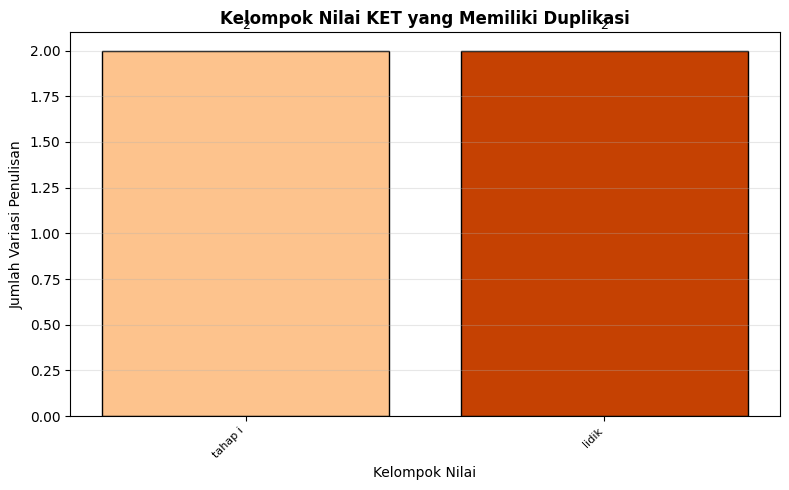

In [48]:
# CHART 3: Bar Chart Jumlah Kelompok Duplikasi
if duplicate_groups:
    plt.figure(figsize=(8, 5))
    dup_df = pd.DataFrame(duplicate_groups)
    colors = plt.cm.Oranges(np.linspace(0.3, 0.8, len(dup_df)))
    bars = plt.bar(range(len(dup_df)), dup_df['JUMLAH_VARIASI'], color=colors, edgecolor='black')
    plt.xticks(range(len(dup_df)), dup_df['VARIASI'], rotation=45, ha='right', fontsize=8)
    plt.title('Kelompok Nilai KET yang Memiliki Duplikasi', fontsize=12, fontweight='bold')
    plt.xlabel('Kelompok Nilai', fontsize=10)
    plt.ylabel('Jumlah Variasi Penulisan', fontsize=10)
    
    for bar, count in zip(bars, dup_df['JUMLAH_VARIASI']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


## RINGKASAN INSPEKSI

In [49]:
# ============================================
# RINGKASAN INSPEKSI
# ============================================
print("\n" + "="*70)
print("RINGKASAN INSPEKSI AWAL:")
print("="*70)
print(f"  ✓ Total baris: {len(df)}")
print(f"  ✓ Kolom KET kosong: {total_empty} baris ({total_empty/len(df)*100:.1f}%)")
print(f"  ✓ Nilai unik KET: {len(unique_values)}")
print(f"  ⚠ Potensi duplikasi: {len(duplicate_groups)} kelompok")



RINGKASAN INSPEKSI AWAL:
  ✓ Total baris: 845
  ✓ Kolom KET kosong: 0 baris (0.0%)
  ✓ Nilai unik KET: 16
  ⚠ Potensi duplikasi: 2 kelompok


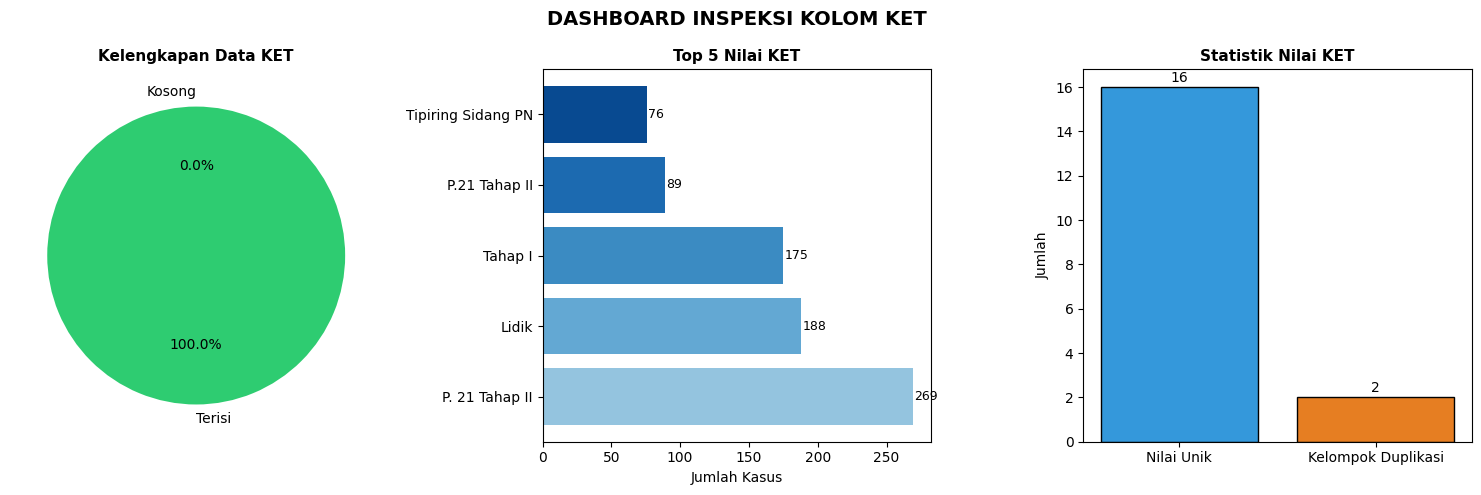


INSPEKSI SELESAI


In [50]:
# CHART 5: Ringkasan Dashboard
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: Data Kosong vs Terisi
labels = ['Terisi', 'Kosong']
sizes = [len(df) - total_empty, total_empty]
colors_donut = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_donut, startangle=90)
axes[0].set_title('Kelengkapan Data KET', fontsize=11, fontweight='bold')

# Subplot 2: Top 5 Nilai KET
top5_ket_values = ket_counts_before.head(5)
axes[1].barh(range(len(top5_ket_values)), top5_ket_values.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top5_ket_values))))
axes[1].set_yticks(range(len(top5_ket_values)))
axes[1].set_yticklabels([str(k)[:25] for k in top5_ket_values.index])
axes[1].set_xlabel('Jumlah Kasus')
axes[1].set_title('Top 5 Nilai KET', fontsize=11, fontweight='bold')
for i, v in enumerate(top5_ket_values.values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)

# Subplot 3: Statistik Nilai Unik
stats_labels = ['Nilai Unik', 'Kelompok Duplikasi']
stats_values = [len(unique_values), len(duplicate_groups)]
colors_stats = ['#3498db', '#e67e22']
axes[2].bar(stats_labels, stats_values, color=colors_stats, edgecolor='black')
axes[2].set_ylabel('Jumlah')
axes[2].set_title('Statistik Nilai KET', fontsize=11, fontweight='bold')
for i, v in enumerate(stats_values):
    axes[2].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=10)

plt.suptitle('DASHBOARD INSPEKSI KOLOM KET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INSPEKSI SELESAI")
print("="*70)

## 7.1 PEMBERSIHAN DAN STANDARISASI KOLOM KET

In [51]:
print("="*70)
print("PEMBERSIHAN DAN STANDARISASI KOLOM KET")
print("="*70)

# Tampilkan nilai unik sebelum pembersihan
print("\n📊 NILAI UNIK SEBELUM PEMBERSIHAN:")
unique_before = df[df['KET'].notna() & (df['KET'] != '')]['KET'].unique()
print(f"   Jumlah: {len(unique_before)}")
for i, val in enumerate(sorted(unique_before), 1):
    print(f"   {i:2d}. '{val}'")

PEMBERSIHAN DAN STANDARISASI KOLOM KET

📊 NILAI UNIK SEBELUM PEMBERSIHAN:
   Jumlah: 16
    1. 'Dilimpahkan ke Polres'
    2. 'LIDIK'
    3. 'LIMPAH POLRES'
    4. 'Lidik'
    5. 'Limpah JPU'
    6. 'Limpah ke JPU'
    7. 'P. 21 Tahap II'
    8. 'P.21 Tahap II'
    9. 'Proses Penyelidikan'
   10. 'Proses Penyidikan'
   11. 'Restorative Justice'
   12. 'TAHAP I'
   13. 'Tahap I'
   14. 'Tahap II '
   15. 'Tahap II tgl 23 April 2022'
   16. 'Tipiring Sidang PN'


## FUNGSI STANDARISASI KET

In [52]:
# ============================================
# FUNGSI STANDARISASI KET
# ============================================

def standardize_ket(value):
    """
    Standarisasi nilai kolom KET
    Menangani:
    - Huruf besar/kecil
    - Spasi berlebih
    - Variasi penulisan yang sama
    """
    if pd.isna(value) or value == '':
        return 'Tidak Ada Keterangan'
    
    # Bersihkan: lowercase, hapus spasi berlebih, hapus karakter khusus
    value_clean = str(value).strip()
    value_lower = value_clean.lower()
    
    # Hapus spasi ganda
    value_lower = re.sub(r'\s+', ' ', value_lower)
    
    # ========================================
    # MAPPING STANDARISASI
    # ========================================
    
    # 1. Untuk Dilimpahkan
    if 'dilimpahkan' in value_lower or 'limpah polres' in value_lower:
        return 'Dilimpahkan ke Polres'
    
    # 2. Untuk Lidik (Penyelidikan)
    if value_lower == 'lidik' or value_lower == 'proses penyelidikan':
        return 'Dalam Lidik'
    
    # 3. Untuk Sidik (Penyidikan)
    if value_lower == 'proses penyidikan':
        return 'Sidik'
    
    # 4. Untuk Limpah ke JPU
    if 'limpah' in value_lower and 'jpu' in value_lower:
        return 'Limpah ke JPU'
    
    # 5. Untuk P.21 Tahap II
    if 'p.21' in value_lower or 'p. 21' in value_lower:
        return 'P.21 Tahap II'
    
    # 6. Untuk Tahap I
    if value_lower == 'tahap i' or value_lower == 'tahap 1':
        return 'Tahap I'
    
    # 7. Untuk Tahap II
    if value_lower.startswith('tahap ii') or value_lower == 'tahap 2':
        # Cek apakah ada tambahan tanggal
        if 'tgl' in value_lower:
            return 'Tahap II'
        return 'Tahap II'
    
    # 8. Untuk Tipiring Sidang PN
    if 'tipiring' in value_lower:
        return 'Tipiring Sidang PN'
    
    # 9. Untuk Restorative Justice
    if 'restorative' in value_lower or value_lower == 'rj':
        return 'Restorative Justice'
    
    # 10. Untuk Tersangka Melarikan Diri
    if 'tsk melarikan diri' in value_lower or 'tersangka melarikan diri' in value_lower:
        return 'Tersangka Melarikan Diri'
    
    # 11. Untuk SP3
    if value_lower == 'sp3':
        return 'SP3'
    
    # Jika tidak dikenali, kembalikan dengan kapitalisasi yang benar
    # Kapitalisasi setiap kata
    words = value_clean.split()
    capitalized = ' '.join([w.capitalize() for w in words])
    return capitalized

# Terapkan standarisasi
df['KET_STD'] = df['KET'].apply(standardize_ket)
print("\n✅ Standarisasi KET selesai. Kolom baru 'KET_STD' telah dibuat.")


✅ Standarisasi KET selesai. Kolom baru 'KET_STD' telah dibuat.


## HASIL SETELAH STANDARISASI

In [53]:
# ============================================
# HASIL SETELAH STANDARISASI
# ============================================
print("\n📊 NILAI UNIK SETELAH STANDARISASI:")
unique_after = df['KET_STD'].unique()
print(f"   Jumlah: {len(unique_after)}")
for i, val in enumerate(sorted(unique_after), 1):
    count = len(df[df['KET_STD'] == val])
    print(f"   {i:2d}. '{val}' ({count} kasus)")



📊 NILAI UNIK SETELAH STANDARISASI:
   Jumlah: 9
    1. 'Dalam Lidik' (193 kasus)
    2. 'Dilimpahkan ke Polres' (7 kasus)
    3. 'Limpah ke JPU' (16 kasus)
    4. 'P.21 Tahap II' (358 kasus)
    5. 'Restorative Justice' (1 kasus)
    6. 'Sidik' (1 kasus)
    7. 'Tahap I' (190 kasus)
    8. 'Tahap II' (3 kasus)
    9. 'Tipiring Sidang PN' (76 kasus)


In [54]:
# ============================================
# PERBANDINGAN SEBELUM VS SESUDAH
# ============================================
print("\n📊 PERBANDINGAN STANDARISASI:")
print("-" * 60)

comparison_data = []
for old_val in sorted(unique_before):
    old_count = len(df[df['KET'] == old_val])
    new_val = standardize_ket(old_val)
    new_count = len(df[df['KET_STD'] == new_val])
    comparison_data.append({
        'Sebelum': old_val,
        'Sesudah': new_val,
        'Jumlah': old_count
    })
    print(f"   '{old_val}' ({old_count} kasus) → '{new_val}'")


📊 PERBANDINGAN STANDARISASI:
------------------------------------------------------------
   'Dilimpahkan ke Polres' (6 kasus) → 'Dilimpahkan ke Polres'
   'LIDIK' (4 kasus) → 'Dalam Lidik'
   'LIMPAH POLRES' (1 kasus) → 'Dilimpahkan ke Polres'
   'Lidik' (188 kasus) → 'Dalam Lidik'
   'Limpah JPU' (15 kasus) → 'Limpah ke JPU'
   'Limpah ke JPU' (1 kasus) → 'Limpah ke JPU'
   'P. 21 Tahap II' (269 kasus) → 'P.21 Tahap II'
   'P.21 Tahap II' (89 kasus) → 'P.21 Tahap II'
   'Proses Penyelidikan' (1 kasus) → 'Dalam Lidik'
   'Proses Penyidikan' (1 kasus) → 'Sidik'
   'Restorative Justice' (1 kasus) → 'Restorative Justice'
   'TAHAP I' (15 kasus) → 'Tahap I'
   'Tahap I' (175 kasus) → 'Tahap I'
   'Tahap II ' (2 kasus) → 'Tahap II'
   'Tahap II tgl 23 April 2022' (1 kasus) → 'Tahap II'
   'Tipiring Sidang PN' (76 kasus) → 'Tipiring Sidang PN'


## FREKUENSI FINAL

In [55]:
# ============================================
# FREKUENSI FINAL
# ============================================
print("\n📊 FREKUENSI KET FINAL (SETELAH STANDARISASI):")
print("-" * 60)

ket_counts = df['KET_STD'].value_counts()
ket_percent = df['KET_STD'].value_counts(normalize=True) * 100

for ket, count in ket_counts.items():
    bar = "█" * int(count / 10)
    print(f"   {ket:30} : {count:4} kasus ({ket_percent[ket]:5.1f}%) {bar}")


📊 FREKUENSI KET FINAL (SETELAH STANDARISASI):
------------------------------------------------------------
   P.21 Tahap II                  :  358 kasus ( 42.4%) ███████████████████████████████████
   Dalam Lidik                    :  193 kasus ( 22.8%) ███████████████████
   Tahap I                        :  190 kasus ( 22.5%) ███████████████████
   Tipiring Sidang PN             :   76 kasus (  9.0%) ███████
   Limpah ke JPU                  :   16 kasus (  1.9%) █
   Dilimpahkan ke Polres          :    7 kasus (  0.8%) 
   Tahap II                       :    3 kasus (  0.4%) 
   Sidik                          :    1 kasus (  0.1%) 
   Restorative Justice            :    1 kasus (  0.1%) 


## GRAFIK DISTRIBUSI KET

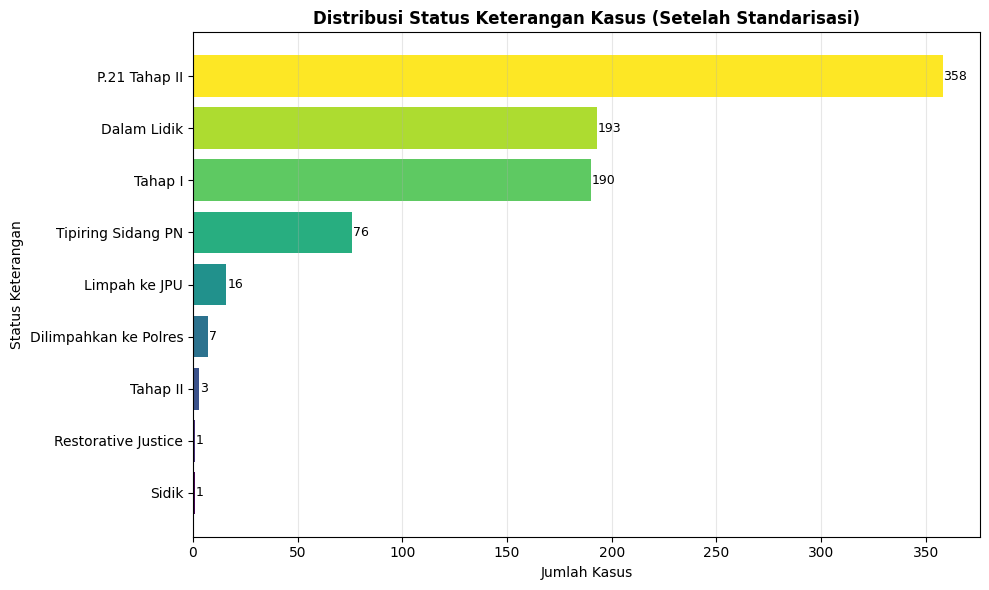

In [56]:
# ============================================
# GRAFIK DISTRIBUSI KET
# ============================================

# 1. Horizontal Bar Chart
plt.figure(figsize=(10, 6))
ket_counts_sorted = ket_counts.sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(ket_counts_sorted)))
bars = plt.barh(ket_counts_sorted.index, ket_counts_sorted.values, color=colors)

for bar, count in zip(bars, ket_counts_sorted.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(count), ha='left', va='center', fontsize=9)

plt.title('Distribusi Status Keterangan Kasus (Setelah Standarisasi)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Kasus', fontsize=10)
plt.ylabel('Status Keterangan', fontsize=10)
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


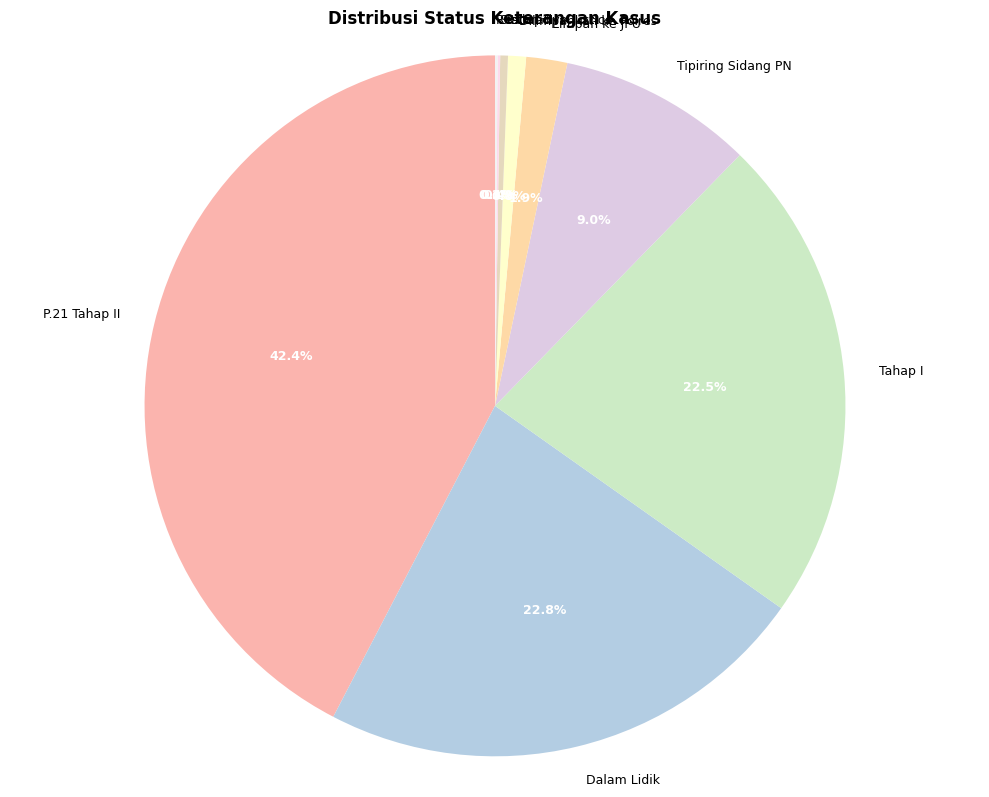

In [57]:

# 2. Pie Chart
plt.figure(figsize=(10, 8))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(ket_counts)))
wedges, texts, autotexts = plt.pie(ket_counts.values, 
                                     labels=ket_counts.index, 
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribusi Status Keterangan Kasus', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## KASUS DENGAN KET BERISI TANGGAL

In [58]:
# ============================================
# CEK KASUS DENGAN TANGGAL DI KET
# ============================================
print("\n📊 KASUS DENGAN KET BERISI TANGGAL:")
print("-" * 60)

# Cari yang mengandung tanggal
date_in_ket = df[df['KET'].astype(str).str.contains('tgl|2022|2023', case=False, na=False)]
if len(date_in_ket) > 0:
    print(f"   Ditemukan {len(date_in_ket)} kasus dengan tanggal di KET:")
    for idx, row in date_in_ket.head(10).iterrows():
        print(f"   - {row['KET']}")
        print(f"     No Laporan: {row['NO_LAPORAN']}, Perkara: {row['PERKARA']}")
else:
    print("   Tidak ada kasus dengan tanggal di KET")



📊 KASUS DENGAN KET BERISI TANGGAL:
------------------------------------------------------------
   Ditemukan 1 kasus dengan tanggal di KET:
   - Tahap II tgl 23 April 2022
     No Laporan: LP/B/64/V/2022/Kalbar/Res Mpw/Sek Sui Pinyuh, Perkara: Penganiayaan


## RINGKASAN AKHIR

In [59]:
# ============================================
# RINGKASAN AKHIR
# ============================================
print("\n" + "="*70)
print("RINGKASAN PEMBERSIHAN KOLOM KET")
print("="*70)

print(f"\n✅ Sebelum standarisasi: {len(unique_before)} nilai unik")
print(f"✅ Setelah standarisasi: {len(ket_counts)} nilai unik")
print(f"✅ Pengurangan: {len(unique_before) - len(ket_counts)} nilai unik (digabung)")

print("\n📊 HASIL AKHIR STATUS KETERANGAN:")
for ket, count in ket_counts.items():
    bar = "█" * int(count / 15)
    print(f"   {ket:30} : {count:4} kasus ({ket_percent[ket]:5.1f}%)")

# Hapus kolom KET asli dan ganti dengan KET_STD
df.drop(columns=['KET'], inplace=True)
df.rename(columns={'KET_STD': 'KET'}, inplace=True)

print("\n" + "="*70)
print("PEMBERSIHAN SELESAI")
print("="*70)


RINGKASAN PEMBERSIHAN KOLOM KET

✅ Sebelum standarisasi: 16 nilai unik
✅ Setelah standarisasi: 9 nilai unik
✅ Pengurangan: 7 nilai unik (digabung)

📊 HASIL AKHIR STATUS KETERANGAN:
   P.21 Tahap II                  :  358 kasus ( 42.4%)
   Dalam Lidik                    :  193 kasus ( 22.8%)
   Tahap I                        :  190 kasus ( 22.5%)
   Tipiring Sidang PN             :   76 kasus (  9.0%)
   Limpah ke JPU                  :   16 kasus (  1.9%)
   Dilimpahkan ke Polres          :    7 kasus (  0.8%)
   Tahap II                       :    3 kasus (  0.4%)
   Sidik                          :    1 kasus (  0.1%)
   Restorative Justice            :    1 kasus (  0.1%)

PEMBERSIHAN SELESAI


# 8. PENANGANAN MISSING VALUE

In [60]:
print("=" * 60)
print("ANALISIS MISSING VALUE")
print("=" * 60)

# 1. Cek missing value per kolom
print("\n📊 Jumlah Missing Value per Kolom:")
missing_info = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Kolom': df.columns,
    'Non-Null Count': df.notnull().sum(),
    'Missing Count': missing_info,
    'Missing %': missing_pct
})
print(missing_summary.to_string(index=False))


ANALISIS MISSING VALUE

📊 Jumlah Missing Value per Kolom:
       Kolom  Non-Null Count  Missing Count  Missing %
  NO_LAPORAN             845              0       0.00
 TGL_LAPORAN             845              0       0.00
     PERKARA             845              0       0.00
         TKP             845              0       0.00
     PELAPOR             836              9       1.07
    TERLAPOR             845              0       0.00
          MO             842              3       0.36
BARANG BUKTI             649            196      23.20
        DESA             845              0       0.00
      PROSES             845              0       0.00
         KET             845              0       0.00


## Detail kolom dengan missing

In [61]:
# 2. Detail kolom dengan missing
print("\n" + "=" * 60)
print("DETAIL KOLOM DENGAN MISSING VALUE")
print("=" * 60)

cols_with_missing = missing_info[missing_info > 0].index.tolist()
for col in cols_with_missing:
    print(f"\n🔍 Kolom: {col}")
    print(f"   Missing: {missing_info[col]} baris ({missing_pct[col]}%)")
    print(f"   Contoh baris dengan data kosong:")
    empty_samples = df[df[col].isnull()].head(3)
    print(f"   Index: {list(empty_samples.index)}")


DETAIL KOLOM DENGAN MISSING VALUE

🔍 Kolom: PELAPOR
   Missing: 9 baris (1.07%)
   Contoh baris dengan data kosong:
   Index: [216, 229, 257]

🔍 Kolom: MO
   Missing: 3 baris (0.36%)
   Contoh baris dengan data kosong:
   Index: [335, 971, 1031]

🔍 Kolom: BARANG BUKTI
   Missing: 196 baris (23.2%)
   Contoh baris dengan data kosong:
   Index: [7, 8, 22]


# 8.1 Isi PELAPOR yang kosong

In [62]:
# ============================================================
# STRATEGI A: Isi PELAPOR yang kosong
# ============================================================

print("\n" + "=" * 60)
print("HANDLE: KOLOM PELAPOR")
print("=" * 60)

# Cek isi kolom PELAPOR yang ada
print("\nContoh isi PELAPOR yang valid:")
print(df['PELAPOR'].dropna().head(10).tolist())

# Strategi: Isi dengan "TIDAK_DIKETAHUI" atau "ANONIM"
print(f"\n✅ Sebelum: {df['PELAPOR'].isnull().sum()} missing")
df['PELAPOR'] = df['PELAPOR'].fillna('TIDAK_DIKETAHUI')

print(f"✅ Sesudah: {df['PELAPOR'].isnull().sum()} missing")
print(f"\nContoh hasil:")
print(df[['PELAPOR', 'PELAPOR']].head(10))


HANDLE: KOLOM PELAPOR

Contoh isi PELAPOR yang valid:
['EMIL PERMATA', 'DINI  ', 'ALFIN LIANG', ' LESTARI IRAWAN', 'EKO YASIN NG', 'BUDI WARDANA BACHTIAR', 'BELLA DWI', 'ZAIN  ', 'AFIF JAFAR SUSANTO', 'HENDRA QODIR']

✅ Sebelum: 9 missing
✅ Sesudah: 0 missing

Contoh hasil:
                  PELAPOR                PELAPOR
0            EMIL PERMATA           EMIL PERMATA
1                  DINI                   DINI  
2             ALFIN LIANG            ALFIN LIANG
3          LESTARI IRAWAN         LESTARI IRAWAN
4            EKO YASIN NG           EKO YASIN NG
5   BUDI WARDANA BACHTIAR  BUDI WARDANA BACHTIAR
7               BELLA DWI              BELLA DWI
8                  ZAIN                   ZAIN  
10     AFIF JAFAR SUSANTO     AFIF JAFAR SUSANTO
11           HENDRA QODIR           HENDRA QODIR


# 8.2 Handle BARANG BUKTI yang kosong

In [63]:
# ============================================================
# STRATEGI B: Handle BARANG BUKTI
# ============================================================

print("\n" + "=" * 60)
print("HANDLE: KOLOM BARANG BUKTI")
print("=" * 60)

# Cek distribusi data yang ada
print("\nContoh isi BARANG BUKTI yang valid:")
print(df['BARANG BUKTI'].head(10).tolist())
print(f"\n✅ Sebelum: {df['BARANG BUKTI'].isnull().sum()} missing")

print("ISI dengan 'TIDAK_ADA_BARANG_BUKTI' (pertahankan semua data)")
df['BARANG BUKTI'] = df['BARANG BUKTI'].fillna('TIDAK_ADA_BARANG_BUKTI')

print(f"✅ Sesudah (kategori): {df['BARANG BUKTI'].isnull().sum()} missing")

print("\nDistribusi BARANG BUKTI:")
print(df['BARANG BUKTI'].value_counts())


HANDLE: KOLOM BARANG BUKTI

Contoh isi BARANG BUKTI yang valid:
['Hasil Visum et Repertum', 'Perhiasan emas', '1 buah HP', 'Timbangan digital', 'Paket klip sabu', '1 unit sepeda motor', nan, nan, 'Paket klip sabu', 'Alat hisap/Bong']

✅ Sebelum: 196 missing
ISI dengan 'TIDAK_ADA_BARANG_BUKTI' (pertahankan semua data)
✅ Sesudah (kategori): 0 missing

Distribusi BARANG BUKTI:
BARANG BUKTI
TIDAK_ADA_BARANG_BUKTI                                                                                         196
Hasil Visum et Repertum                                                                                         48
Bukti transfer / Kwitansi                                                                                       42
Pecahan kaca/barang rusak                                                                                       36
Hasil Visum et Repertum.                                                                                        24
                                  

# 8.3 HANDLE KOLOM MO yang kosong

In [64]:
# ============================================================
# HANDLE: KOLOM MO (untuk text preprocessing)
# ============================================================

print("\n" + "=" * 60)
print("HANDLE: KOLOM MO (Text Preprocessing)")
print("=" * 60)

# Cek missing di MO
print(f"\nMissing di MO: {df['MO'].isnull().sum()}")
print(f"Kosong/string kosong: {(df['MO'] == '').sum()}")
print(f"Whitespace only: {df['MO'].str.strip().eq('').sum()}")

# Bersihkan/Hapus MO
print(f"\nproses membersihkan MO...")
df = df.dropna(subset=['MO'])
print(f"Missing di MO: {df['MO'].isnull().sum()}")

print(f"\n✅ MO siap untuk preprocessing")
print(f"Contoh MO:")
print(df['MO'].head(10).tolist())


HANDLE: KOLOM MO (Text Preprocessing)

Missing di MO: 3
Kosong/string kosong: 0
Whitespace only: 0

proses membersihkan MO...
Missing di MO: 0

✅ MO siap untuk preprocessing
Contoh MO:
['Pelaku merasa tersinggung dengan tatapan korban saat berpapasan di jalan, lalu memukul wajah korban dengan tangan kosong.', 'Pelaku berpura-pura menjadi tamu/pembeli, saat korban lengah pelaku membawa lari motor korban.', 'Pelaku berpura-pura menjadi tamu/pembeli, saat korban lengah pelaku menguras isi laci kasir.', 'Petugas mencurigai gerak-gerik pelaku di pinggir jalan, saat digeledah ditemukan 2 paket ganja kering siap edar yang disembunyikan di dalam bungkus rokok.', 'Petugas mencurigai gerak-gerik pelaku di pinggir jalan, saat digeledah ditemukan 2 paket ganja kering siap edar yang disembunyikan di bawah jok motor.', 'Pelaku merusak kunci stang motor menggunakan kunci T saat motor diparkir di Gg. Damai RT 20/RW 05, Galang, Kec. Sungai Pinyuh, Kab. Mempawah, lalu membawanya kabur.', 'Pelaku merusa

# 9. Cek variabel duplikat pada kolom MO BARANG BUKTI dan PERKARA

In [65]:
duplicate_count = df.duplicated(
    subset=['MO', 'BARANG BUKTI', 'PERKARA']
).sum()

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 250


## Data yang Terlibat Duplikasi

In [66]:
duplicate_rows = df[
    df.duplicated(
        subset=['MO', 'BARANG BUKTI', 'PERKARA'],
        keep=False
    )
]

print(f"Jumlah baris terlibat duplikasi: {len(duplicate_rows)}")

duplicate_rows[
    ['PERKARA','BARANG BUKTI','MO']
].head(20)

Jumlah baris terlibat duplikasi: 356


,PERKARA,BARANG BUKTI,MO
0,Penganiayaan,Hasil Visum et Repertum,Pelaku merasa tersinggung dengan tatapan korba...
2,Pencurian,1 buah HP,"Pelaku berpura-pura menjadi tamu/pembeli, saat..."
11,Narkoba,Alat hisap/Bong,Pelaku tertangkap tangan saat hendak melakukan...
20,Penganiayaan,Pecahan piring (jika ada),Pelaku menagih hutang kepada korban namun korb...
24,Pencurian,perhiasan emas seberat 10 gram,Pelaku masuk melalui pintu belakang yang tidak...
32,Pencurian,Tabung gas,"Pelaku berpura-pura menjadi tamu/pembeli, saat..."
37,Penipuan,Bukti transfer,Pelaku mengajak korban kerjasama bisnis jual b...
39,Narkoba,Alat hisap/Bong,Pelaku tertangkap tangan saat hendak melakukan...
42,Penipuan,Screenshot percakapan,Pelaku menawarkan barang elektronik black mark...
47,Perusakan,Batu,"Karena marah tidak diberi uang keamanan, pelak..."


## Kelompok Duplikasi

In [67]:
duplicate_groups = (
    df.groupby(
        ['MO','BARANG BUKTI','PERKARA']
    )
    .size()
    .reset_index(name='FREKUENSI')
    .query('FREKUENSI > 1')
    .sort_values(
        'FREKUENSI',
        ascending=False
    )
)

duplicate_groups

,MO,BARANG BUKTI,PERKARA,FREKUENSI
381,Pelaku menjanjikan pekerjaan kepada korban den...,Bukti transfer / Kwitansi,Penipuan,13
558,Tertangkap tangan memiliki dan menyimpan narko...,1 klip plastik transparan berisi serbuk krista...,Narkoba,10
269,Pelaku menampar pipi korban sebelah kiri karen...,TIDAK_ADA_BARANG_BUKTI,Penganiayaan,9
256,Pelaku memukul wajah korban dengan tangan koso...,"Hasil Visum et Repertum, 1 potong kayu.",Penganiayaan,9
218,Pelaku memecahkan kaca mobil korban menggunaka...,Pecahan kaca/barang rusak,Perusakan,9
...,...,...,...,...
460,Pelapor terkejut melihat pagar rumah miliknya ...,"Pecahan rumah, Foto kerusakan.",Perusakan,2
547,Terjadi tindak pidana penganiayaan yang dilaku...,Hasil Visum et Repertum.,Penganiayaan,2
560,"Tertangkap tangan memiliki, menyimpan, dan men...",2 butir pil ekstasi,Narkoba,2
562,"Tertangkap tangan memiliki, menyimpan, dan men...",alat hisap sabu (bong),Narkoba,2


## Visualisasi

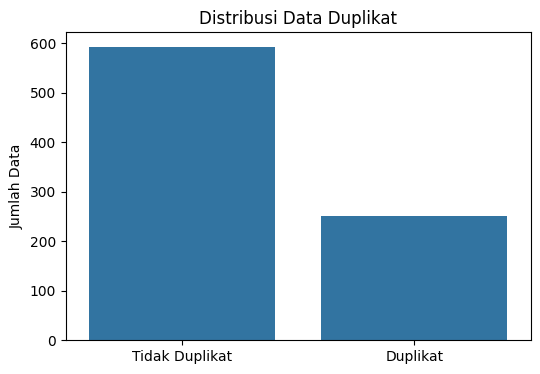

In [68]:
duplicate_count = df.duplicated(
    subset=['MO','BARANG BUKTI','PERKARA']
).sum()

non_duplicate_count = len(df) - duplicate_count

plt.figure(figsize=(6,4))

sns.barplot(
    x=['Tidak Duplikat','Duplikat'],
    y=[non_duplicate_count, duplicate_count]
)

plt.title('Distribusi Data Duplikat')
plt.ylabel('Jumlah Data')

plt.show()

## Hapus Duplikasi

In [69]:
before = len(df)

df = df.drop_duplicates(
    subset=['MO','BARANG BUKTI','PERKARA']
)

after = len(df)

print(f"Sebelum : {before}")
print(f"Sesudah : {after}")
print(f"Dihapus : {before-after}")

Sebelum : 842
Sesudah : 592
Dihapus : 250


## Verifikasi

In [70]:
df.duplicated(
    subset=['MO','BARANG BUKTI','PERKARA']
).sum()

np.int64(0)

# 10. preprocessing text
## CEK MISSING VALUE

In [71]:
print("=" * 60)
print("CEK MISSING VALUE SETELAH PENANGANAN")
print("=" * 60)

missing = df[['MO', 'BARANG BUKTI', 'PERKARA']].isnull().sum()

print(missing)

if missing.sum() == 0:
    print("\n✅ Tidak ditemukan missing value")
else:
    print("\n⚠️ Masih terdapat missing value")

CEK MISSING VALUE SETELAH PENANGANAN
MO              0
BARANG BUKTI    0
PERKARA         0
dtype: int64

✅ Tidak ditemukan missing value


In [72]:
print("\n📊 DATASET SETELAH MISSING VALUE DAN DUPLIKASI")
print("-" * 60)

print(f"Jumlah data : {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")

print("\nKolom yang digunakan:")
print("- MO")
print("- BARANG BUKTI")
print("- PERKARA")

print("\nContoh data:")
print(
    df[
        ['PERKARA', 'MO', 'BARANG BUKTI']
    ].head(5).to_string()
)


📊 DATASET SETELAH MISSING VALUE DAN DUPLIKASI
------------------------------------------------------------
Jumlah data : 592
Jumlah kolom: 11

Kolom yang digunakan:
- MO
- BARANG BUKTI
- PERKARA

Contoh data:
        PERKARA                                                                                                                                                          MO             BARANG BUKTI
0  Penganiayaan                                   Pelaku merasa tersinggung dengan tatapan korban saat berpapasan di jalan, lalu memukul wajah korban dengan tangan kosong.  Hasil Visum et Repertum
1     Pencurian                                                              Pelaku berpura-pura menjadi tamu/pembeli, saat korban lengah pelaku membawa lari motor korban.           Perhiasan emas
2     Pencurian                                                                Pelaku berpura-pura menjadi tamu/pembeli, saat korban lengah pelaku menguras isi laci kasir.                1 buah HP
3 

## 10.1 Cleaning

In [73]:
# ============================================================
# FUNGSI CLEANING
# ============================================================

def cleaning(text):
    """
    Membersihkan teks:
    - hapus tanda baca
    - hapus karakter aneh
    - pertahankan huruf dan angka
    - rapikan spasi
    """

    if pd.isna(text) or str(text).strip() == "":
        return ""

    text = str(text)

    # Ganti tanda baca menjadi spasi
    text = re.sub(
        rf"[{re.escape(string.punctuation)}]",
        " ",
        text
    )

    # Hanya huruf, angka, dan spasi
    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        ' ',
        text
    )

    # Rapikan spasi
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text



In [74]:
# Terapkan cleaning pada kolom MO dan kolom BARANG BUKTI
df['MO_clean'] = df['MO'].apply(cleaning)

df['BB_clean'] = df['BARANG BUKTI'].apply(cleaning)

# Tampilkan contoh
print("=" * 50)
print("HASIL CLEANING KOLOM MO:")
print("=" * 50)
print(df[['MO', 'MO_clean']].head(10).to_string())

print("\n" + "=" * 50)
print("HASIL CLEANING KOLOM BARANG BUKTI:")
print("=" * 50)
print(df[['BARANG BUKTI', 'BB_clean']].head(10).to_string())

HASIL CLEANING KOLOM MO:
                                                                                                                                                                                                                MO                                                                                                                                                                                                MO_clean
0                                                                                        Pelaku merasa tersinggung dengan tatapan korban saat berpapasan di jalan, lalu memukul wajah korban dengan tangan kosong.                                                                                 Pelaku merasa tersinggung dengan tatapan korban saat berpapasan di jalan lalu memukul wajah korban dengan tangan kosong
1                                                                                                                   Pelaku berpura-pura menjadi tamu/pemb

## 10.2 case folding

In [75]:
# ============================================================
# FUNGSI CASE FOLDING
# ============================================================
    
def case_folding(text):
    """
    Mengubah teks menjadi huruf kecil (lowercase)
    """

    if pd.isna(text) or str(text).strip() == "":
        return ""

    return str(text).lower().strip()

In [76]:
# Terapkan case folding
df['MO_casefold'] = df['MO_clean'].apply(case_folding)

df['BB_casefold'] = df['BB_clean'].apply(case_folding)

# Tampilkan contoh
print("=" * 60)
print("HASIL CASE FOLDING - MO")
print("=" * 60)

print(
    df[['MO_clean', 'MO_casefold']]
    .sample(5, random_state=42)
    .to_string()
)

print("=" * 60)
print("HASIL CASE FOLDING - BARANG BUKTI")
print("=" * 60)

print(
    df[['BB_clean', 'BB_casefold']]
    .sample(5, random_state=42)
    .to_string()
)

HASIL CASE FOLDING - MO
                                                                                                                                                                                    MO_clean                                                                                                                                                                             MO_casefold
872                                                                                                                Pelaku Lidik memukul wajah korban dengan tangan kosong karena salah paham                                                                                                               pelaku lidik memukul wajah korban dengan tangan kosong karena salah paham
1044  Pelaku melihat 1 unit Laptop ASUS yang diletakkan korban di Jl Budi Utomo Desa Kel Sungai Bakau Besar Darat Kec Sungai Pinyuh kemudian dengan cepat mengambil barang berharga tersebut  pelaku melihat 1 unit laptop asus yang d

## 10.3 Normalisasi

In [77]:
# ======================
# BACA KAMUS
# ======================

kamus_df = pd.read_excel('../data/raw/kamuskatabaku.xlsx')

# Hapus header duplikat jika ada
kamus_df = kamus_df[
    kamus_df['tidak_baku'] != 'tidak_baku'
].reset_index(drop=True)

# lowercase supaya konsisten
kamus_df['tidak_baku'] = (
    kamus_df['tidak_baku']
    .astype(str)
    .str.lower()
    .str.strip()
)

kamus_df['kata_baku'] = (
    kamus_df['kata_baku']
    .astype(str)
    .str.lower()
    .str.strip()
)

# dictionary
kamus_dict = dict(
    zip(
        kamus_df['tidak_baku'],
        kamus_df['kata_baku']
    )
)

kamus_tambahan = {

    # singkatan umum
    'tkp': 'tempat kejadian perkara',
    'lp': 'laporan polisi',
    'sdr': 'saudara',
    'sdri': 'saudari',
    'tsk': 'tersangka',

    # normalisasi istilah perkara
    'merusak': 'rusak',
    'perusakan': 'rusak',
    'kerusakan': 'rusak',
    'pencurian': 'curi',

    # variasi narkoba
    'shabu': 'sabu',

    # variasi penulisan
    'ponsel': 'handphone',
    'merk': 'merek',
    
    'hillang': 'hilang',
    'try': 'tri',
    'bateri': 'baterai',
    'coex': 'coaxial',
    'mengecek': 'cek',
    'ceeder cable' : 'kabel feeder',
    'Jumper Cable': 'Kabel jumper',
    
}

kamus_dict.update(kamus_tambahan)

In [78]:
# ============================================================
# FUNGSI NORMALISASI
# ============================================================

def normalisasi(text, kamus):
    """
    Mengubah kata tidak baku menjadi baku
    """

    if pd.isna(text) or text == "":
        return ""

    words = text.split()

    normalized_words = [
        kamus.get(word, word)
        for word in words
    ]

    return ' '.join(normalized_words)

In [79]:
# ============================================================
# APLIKASI NORMALISASI KE KOLOM MO
# ============================================================

df['MO_normalized'] = df['MO_casefold'].apply(
    lambda x: normalisasi(x, kamus_dict)
)

df['BB_normalized'] = df['BB_casefold'].apply(
    lambda x: normalisasi(x, kamus_dict)
)

# ============================================================
# TAMPILKAN HASIL
# ============================================================

print("\n" + "=" * 60)
print("HASIL CLEANING → CASE FOLDING → NORMALISASI")
print("=" * 60)

# Tampilkan contoh perbandingan
print( df[
    ['MO', 'MO_clean', 'MO_casefold', 'MO_normalized']
].sample(15, random_state=42).to_string())

print("\n" + "=" * 60)
print("HASIL CLEANING → CASE FOLDING → NORMALISASI")
print("=" * 60)

print( df[
    ['BARANG BUKTI', 'BB_clean', 'BB_casefold', 'BB_normalized']
].sample(15, random_state=42).to_string())


HASIL CLEANING → CASE FOLDING → NORMALISASI
                                                                                                                                                                                                                                    MO                                                                                                                                                                                                                       MO_clean                                                                                                                                                                                                                    MO_casefold                                                                                                                                                                                                                  MO_normalized
872                                                    

In [80]:
changed_MO = df[
    df['MO_casefold'] != df['MO_normalized']
]

changed_BB = df[
    df['BB_casefold'] != df['BB_normalized']
]


print(f"Jumlah data yang berubah setelah normalisasi: {len(changed_MO)}")
print(f"Jumlah data yang berubah setelah normalisasi: {len(changed_BB)}")


Jumlah data yang berubah setelah normalisasi: 250
Jumlah data yang berubah setelah normalisasi: 87


In [81]:
changed_MO[
    ['MO_casefold', 'MO_normalized']
].head(10)
changed_BB[
    ['BB_casefold', 'BB_normalized']
].head(10)

,BB_casefold,BB_normalized
2,1 buah hp,1 buah handphone
17,1 satu unit hp,1 satu unit handphone
25,1 satu unit ranmor merk honda supra x 125 kb 5...,1 satu unit ranmor merek honda supra kali 125 ...
26,1 satu unit hp,1 satu unit handphone
27,1 satu unit hp merk oppo,1 satu unit handphone merek oppo
34,1 buah hp,1 buah handphone
46,foto kerusakan,foto rusak
52,1 buah hp,1 buah handphone
55,foto kerusakan,foto rusak
68,1 satu unit sepeda motor merk honda beat warna...,1 satu unit sepeda motor merek honda beat warn...


## 10.4 TOKENISASI

In [82]:
# ============================================================
# FUNGSI TOKENISASI
# ============================================================

def tokenisasi(text):
    """
    Tokenisasi unigram
    """

    if pd.isna(text) or text == "":
        return []

    return text.split()

In [83]:
# ============================================================
# APLIKASI TOKENISASI KE DATAFRAME
# ============================================================

df['MO_tokens'] = df['MO_normalized'].apply(tokenisasi)
df['BB_tokens'] = df['BB_normalized'].apply(tokenisasi)

# ============================================================
# TAMPILKAN HASIL TOKENISASI
# ============================================================

print("=" * 70)
print("HASIL TOKENISASI")
print("=" * 70)

sample_cols = ['MO', 'MO_clean', 'MO_casefold', 'MO_normalized', 'MO_tokens']
print(df[sample_cols].sample(10, random_state=42).to_string())

sample_cols = ['BARANG BUKTI', 'BB_clean', 'BB_casefold', 'BB_normalized', 'BB_tokens']
print(df[sample_cols].sample(10, random_state=42).to_string())

HASIL TOKENISASI
                                                                                                                                                                                                 MO                                                                                                                                                                                MO_clean                                                                                                                                                                             MO_casefold                                                                                                                                                                                         MO_normalized                                                                                                                                                                                                                           MO_

In [84]:
df['MO_token_count'] = df['MO_tokens'].apply(len)
df['BB_token_count'] = df['BB_tokens'].apply(len)

print("\nStatistik jumlah token di MO:")
print(df['MO_token_count'].describe())
print("\nStatistik jumlah token di BARANG BUKTI:")
print(df['BB_token_count'].describe())


Statistik jumlah token di MO:
count    592.000000
mean      19.888514
std       10.101066
min        5.000000
25%       14.000000
50%       17.000000
75%       22.000000
max       97.000000
Name: MO_token_count, dtype: float64

Statistik jumlah token di BARANG BUKTI:
count    592.000000
mean       4.922297
std        4.874122
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max       61.000000
Name: BB_token_count, dtype: float64


## 10.5 STOPWORD REMOVAL

In [85]:
#  import library
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

important_words = {
    'korban',
    'pelaku',
    'tersangka',
    'terlapor',
    'sabu',
    'kunci',
    'rusak',
    'tower',
    'feeder',
    'jumper',
    'genset',
    'konektor',
    'kabel',
    'baterai',
    'aki',
    'coaxial',
    'dodu',
    'gembok',
    'hilang'
}

stop_words = stop_words - important_words


custom_stopwords = {
    'unit',
    'buah',
    'lembar',
    'batang',
    'biji',
    'helai',
    'pucuk',
    'paket',
    'bungkus',
    'barang',
    'bukti',
    'sungai',
    'kecamatan',
    'kabupaten',
    'rukun',
    'warga',
    'tetangga',
    'pinyuh',
    'peniraman',
    'mempawah',
    'desa',
    'dusun',
    'jalan',
    'gang',
    'pcs',
    'meter',
    'rupiah',
    'puluh',
    'enam',
    'via',
    'langsung',
    'pusat',
    'merek',
    'apm',
    'moc',
    'bts',
}

stop_words = stop_words.union(custom_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ariar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [86]:
# ============================================================
# FUNGSI STOPWORD REMOVAL
# ============================================================

def stopword_removal(tokens):
    """
    Menghapus:
    - stopword
    - kata dengan panjang <= 2 huruf
    - kata yang hanya angka
    """

    if not tokens:
        return []

    return [
        word
        for word in tokens
        if word not in stop_words
        and len(word) > 2
        and not any(char.isdigit() for char in word)
    ]

In [87]:
# ============================================================
# APLIKASI STOPWORD REMOVAL KE KOLOM MO_tokens
# ============================================================

df['MO_stopwords'] = df['MO_tokens'].apply(stopword_removal)
df['BB_stopwords'] = df['BB_tokens'].apply(stopword_removal)

# ============================================================
# TAMPILKAN HASIL STOPWORD REMOVAL
# ============================================================

print("=" * 70)
print("HASIL STOPWORD REMOVAL")
print("=" * 70)

sample_cols = ['MO', 'MO_clean', 'MO_casefold', 'MO_normalized', 'MO_tokens', 'MO_stopwords']
print(df[sample_cols].sample(10, random_state=42).to_string())

sample_cols = ['BARANG BUKTI', 'BB_clean', 'BB_casefold', 'BB_normalized', 'BB_tokens', 'BB_stopwords']
print(df[sample_cols].sample(10, random_state=42).to_string())

HASIL STOPWORD REMOVAL
                                                                                                                                                                                                 MO                                                                                                                                                                                MO_clean                                                                                                                                                                             MO_casefold                                                                                                                                                                                         MO_normalized                                                                                                                                                                                                                        

In [88]:
from collections import Counter

all_tokens = [
    token
    for tokens in df['MO_stopwords']
    for token in tokens
]

all_tokens_bb = [
    token
    for tokens in df['BB_stopwords']
    for token in tokens
]

print("\n" + "=" * 70)
print("50 KATA PALING SERING MUNCUL DI MO (SETELAH STOPWORD REMOVAL)")
print("=" * 70)
print(
Counter(all_tokens).most_common(50)
)
print("\n" + "=" * 70)
print("50 KATA PALING SERING MUNCUL DI BARANG BUKTI (SETELAH STOPWORD REMOVAL)")
print("=" * 70)
print(
Counter(all_tokens_bb).most_common(50)
)


50 KATA PALING SERING MUNCUL DI MO (SETELAH STOPWORD REMOVAL)
[('pelaku', 602), ('korban', 484), ('mengambil', 164), ('rumah', 123), ('motor', 119), ('rusak', 116), ('uang', 105), ('milik', 78), ('masuk', 72), ('kunci', 71), ('pintu', 64), ('memukul', 53), ('kosong', 51), ('pelapor', 49), ('sepeda', 48), ('tangan', 47), ('tersangka', 45), ('handphone', 42), ('akibat', 41), ('petugas', 39), ('jendela', 39), ('mobil', 37), ('menghilang', 37), ('keluarga', 34), ('diparkir', 33), ('sabu', 33), ('curi', 30), ('mulut', 30), ('alasan', 29), ('emosi', 29), ('menawarkan', 28), ('orang', 27), ('gram', 27), ('pura', 26), ('ditemukan', 26), ('diletakkan', 25), ('kaca', 25), ('pagar', 25), ('wajah', 24), ('berpura', 24), ('lengah', 24), ('kabur', 24), ('harga', 24), ('meminjam', 24), ('tempo', 24), ('membawa', 23), ('murah', 23), ('informasi', 23), ('terkunci', 23), ('seberat', 23)]

50 KATA PALING SERING MUNCUL DI BARANG BUKTI (SETELAH STOPWORD REMOVAL)
[('motor', 58), ('sepeda', 48), ('uang', 44

In [89]:
before_MO = df['MO_tokens'].apply(len).sum()
after_MO = df['MO_stopwords'].apply(len).sum()
removed_MO = before_MO - after_MO

print(f"Token MO : ")
print(f"Token sebelum : {before_MO}")
print(f"Token sesudah : {after_MO}")
print(f"Token dihapus : {removed_MO}")

before_BB = df['BB_tokens'].apply(len).sum()
after_BB = df['BB_stopwords'].apply(len).sum()
removed_BB = before_BB - after_BB

print(f"\nToken BARANG BUKTI : ")
print(f"Token sebelum : {before_BB}")
print(f"Token sesudah : {after_BB}")
print(f"Token dihapus : {removed_BB}")

Token MO : 
Token sebelum : 11774
Token sesudah : 7069
Token dihapus : 4705

Token BARANG BUKTI : 
Token sebelum : 2914
Token sesudah : 1445
Token dihapus : 1469


## 10.6 STEMMING

In [90]:

# Install Sastrawi jika belum: pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Daftar kata yang tidak boleh di-stem
KATA_DASAR = {
    # aktor
    'pelaku',
    'petugas',
    'tersangka',
    'terlapor',
    'pemilik',
    'penjual',
    'pembeli',
    'penumpang',
    'pengemudi',
    'penghuni',
    'pengunjung',
    'tertuduh',
    'terdakwa',

    # benda
    'motor',
    'mobil',
    'handphone',
    'laptop',

    # istilah hukum
    'laporan',
    'tabungan',
    'kiriman',
    'titipan',

    # narkotika
    'sabu',
    'ganja',
    'ekstasi',

    # kata yang rawan overstemming
    'rusak',

    # pengecualian lain
    'belur'
}


In [91]:
# ============================================================
# FUNGSI STEMMING DENGAN SASTRAWI (abaikan KATA_DASAR)
# ============================================================

def stemming(tokens):
    """
    Stemming token
    """
    
    if not tokens:
        return []

    return [
        token
        if token in KATA_DASAR
        else stemmer.stem(token)
        for token in tokens
    ]


In [92]:
# ============================================================
# APLIKASI STEMMING KE KOLOM MO_stopwords
# ============================================================

df['MO_tokens_stemmed'] = df['MO_stopwords'].apply(stemming)
df['BB_tokens_stemmed'] = df['BB_stopwords'].apply(stemming)

# ============================================================
# TAMPILKAN HASIL STEMMING
# ============================================================

print("=" * 70)
print("HASIL STEMMING")
print("=" * 70)

sample_cols = ['MO', 'MO_clean', 'MO_casefold', 'MO_normalized', 'MO_tokens', 'MO_stopwords', 'MO_tokens_stemmed']
print(df[sample_cols].head(10).to_string())

sample_cols = ['BARANG BUKTI', 'BB_clean', 'BB_casefold', 'BB_normalized', 'BB_tokens', 'BB_stopwords', 'BB_tokens_stemmed']
print(df[sample_cols].head(10).to_string())

HASIL STEMMING
                                                                                                                                                                                                                MO                                                                                                                                                                                                MO_clean                                                                                                                                                                                             MO_casefold                                                                                                                                                                                                                               MO_normalized                                                                                                                                           

In [93]:
for sebelum, sesudah in zip(
    df['MO_stopwords'].head(5),
    df['MO_tokens_stemmed'].head(5)
):
    print(sebelum)
    print(sesudah)
    print('-' * 50)

['pelaku', 'tersinggung', 'tatapan', 'korban', 'berpapasan', 'memukul', 'wajah', 'korban', 'tangan', 'kosong']
['pelaku', 'singgung', 'tatap', 'korban', 'papas', 'pukul', 'wajah', 'korban', 'tangan', 'kosong']
--------------------------------------------------
['pelaku', 'berpura', 'pura', 'tamu', 'pembeli', 'korban', 'lengah', 'pelaku', 'membawa', 'lari', 'motor', 'korban']
['pelaku', 'pura', 'pura', 'tamu', 'pembeli', 'korban', 'lengah', 'pelaku', 'bawa', 'lari', 'motor', 'korban']
--------------------------------------------------
['pelaku', 'berpura', 'pura', 'tamu', 'pembeli', 'korban', 'lengah', 'pelaku', 'menguras', 'isi', 'laci', 'kasir']
['pelaku', 'pura', 'pura', 'tamu', 'pembeli', 'korban', 'lengah', 'pelaku', 'uras', 'isi', 'laci', 'kasir']
--------------------------------------------------
['petugas', 'mencurigai', 'gerak', 'gerik', 'pelaku', 'pinggir', 'digeledah', 'ditemukan', 'ganja', 'kering', 'edar', 'disembunyikan', 'rokok']
['petugas', 'curiga', 'gerak', 'gerik', 'p

In [94]:
for sebelum, sesudah in zip(
    df['BB_stopwords'].head(5),
    df['BB_tokens_stemmed'].head(5)
):
    print(sebelum)
    print(sesudah)
    print('-' * 50)

['hasil', 'visum', 'repertum']
['hasil', 'visum', 'repertum']
--------------------------------------------------
['perhiasan', 'emas']
['hias', 'emas']
--------------------------------------------------
['handphone']
['handphone']
--------------------------------------------------
['timbangan', 'digital']
['timbang', 'digital']
--------------------------------------------------
['klip', 'sabu']
['klip', 'sabu']
--------------------------------------------------


In [95]:
from collections import Counter

all_tokens = []
all_tokens_bb = []

for tokens in df['MO_tokens_stemmed']:
    all_tokens.extend(tokens)

for tokens in df['BB_tokens_stemmed']:
    all_tokens_bb.extend(tokens)

print("\n" + "=" * 70)
print("30 KATA PALING SERING MUNCUL DI MO (SETELAH STEMMING)")
print("=" * 70)
print(
Counter(all_tokens).most_common(30)
)
print("\n" + "=" * 70)
print("30 KATA PALING SERING MUNCUL DI BARANG BUKTI (SETELAH STEMMING)")
print("=" * 70)
print(
Counter(all_tokens_bb).most_common(30)
)


30 KATA PALING SERING MUNCUL DI MO (SETELAH STEMMING)
[('pelaku', 602), ('korban', 484), ('ambil', 164), ('rumah', 124), ('motor', 123), ('rusak', 120), ('milik', 108), ('uang', 105), ('kunci', 96), ('masuk', 72), ('pintu', 64), ('pukul', 61), ('parkir', 59), ('kosong', 51), ('pura', 50), ('lapor', 50), ('sepeda', 48), ('tangan', 47), ('hilang', 46), ('tersangka', 45), ('akibat', 43), ('handphone', 42), ('bawa', 40), ('petugas', 39), ('harga', 39), ('jendela', 39), ('curi', 38), ('mobil', 37), ('isi', 34), ('keluarga', 34)]

30 KATA PALING SERING MUNCUL DI BARANG BUKTI (SETELAH STEMMING)
[('motor', 58), ('sepeda', 48), ('uang', 44), ('handphone', 43), ('transfer', 41), ('kwitansi', 40), ('hasil', 39), ('visum', 39), ('repertum', 37), ('tunai', 36), ('emas', 30), ('hias', 29), ('pecah', 28), ('kotak', 28), ('dus', 26), ('screenshot', 24), ('alat', 23), ('honda', 22), ('surat', 21), ('laptop', 21), ('sabu', 20), ('warna', 20), ('tabung', 19), ('gas', 19), ('yamaha', 19), ('rusak', 18), 

# 10.7 text final
## gabung hasil preprocessing MO dan BB

In [96]:
df['MO_final_text'] = (
    df['MO_tokens_stemmed']
    .apply(lambda x: ' '.join(x))
)

df['BB_final_text'] = (
    df['BB_tokens_stemmed']
    .apply(lambda x: ' '.join(x))
)

# 9. Simpan Hasil

In [97]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 592 entries, 0 to 1049
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   NO_LAPORAN         592 non-null    object
 1   TGL_LAPORAN        592 non-null    object
 2   PERKARA            592 non-null    object
 3   TKP                592 non-null    object
 4   PELAPOR            592 non-null    object
 5   TERLAPOR           592 non-null    object
 6   MO                 592 non-null    object
 7   BARANG BUKTI       592 non-null    object
 8   DESA               592 non-null    object
 9   PROSES             592 non-null    object
 10  KET                592 non-null    object
 11  MO_clean           592 non-null    object
 12  BB_clean           592 non-null    object
 13  MO_casefold        592 non-null    object
 14  BB_casefold        592 non-null    object
 15  MO_normalized      592 non-null    object
 16  BB_normalized      592 non-null    object
 17  M

,NO_LAPORAN,TGL_LAPORAN,PERKARA,TKP,PELAPOR,TERLAPOR,MO,BARANG BUKTI,DESA,PROSES,...,MO_tokens,BB_tokens,MO_token_count,BB_token_count,MO_stopwords,BB_stopwords,MO_tokens_stemmed,BB_tokens_stemmed,MO_final_text,BB_final_text
0,LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,1 Januari 2021,Penganiayaan,"Dusun Melati, Sungai Purun Kecil, Kec. Sungai ...",EMIL PERMATA,LIE,Pelaku merasa tersinggung dengan tatapan korba...,Hasil Visum et Repertum,Sungai Purun Kecil,SIDIK,...,"[pelaku, merasa, tersinggung, dengan, tatapan,...","[hasil, visum, et, repertum]",17,4,"[pelaku, tersinggung, tatapan, korban, berpapa...","[hasil, visum, repertum]","[pelaku, singgung, tatap, korban, papas, pukul...","[hasil, visum, repertum]",pelaku singgung tatap korban papas pukul wajah...,hasil visum repertum
1,LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,1 Januari 2021,Pencurian,"Gg. Usaha RT 20/RW 09, Sungai Batang, Kec. Sun...",DINI,PASARIBU,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",Perhiasan emas,Sungai Batang,SIDIK,...,"[pelaku, berpura, pura, menjadi, tamu, pembeli...","[perhiasan, emas]",14,2,"[pelaku, berpura, pura, tamu, pembeli, korban,...","[perhiasan, emas]","[pelaku, pura, pura, tamu, pembeli, korban, le...","[hias, emas]",pelaku pura pura tamu pembeli korban lengah pe...,hias emas
2,LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,4 Januari 2021,Pencurian,"Jl. Raya Nusapati RT 09/RW 05, Sungai Purun Ke...",ALFIN LIANG,FIKA,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",1 buah HP,Sungai Purun Kecil,SIDIK,...,"[pelaku, berpura, pura, menjadi, tamu, pembeli...","[1, buah, handphone]",14,3,"[pelaku, berpura, pura, tamu, pembeli, korban,...",[handphone],"[pelaku, pura, pura, tamu, pembeli, korban, le...",[handphone],pelaku pura pura tamu pembeli korban lengah pe...,handphone
3,LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,5 Januari 2021,Narkoba,"Dusun Sejahtera, Sungai Batang, Kec. Sungai Pi...",LESTARI IRAWAN,MANSUR FAJAR,Petugas mencurigai gerak-gerik pelaku di pingg...,Timbangan digital,Sungai Batang,DALAM LIDIK,...,"[petugas, mencurigai, gerak, gerik, pelaku, di...","[timbangan, digital]",23,2,"[petugas, mencurigai, gerak, gerik, pelaku, pi...","[timbangan, digital]","[petugas, curiga, gerak, gerik, pelaku, pinggi...","[timbang, digital]",petugas curiga gerak gerik pelaku pinggir gele...,timbang digital
4,LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh,5 Januari 2021,Narkoba,"Gg. Famili, Desa/Kel. Peniraman, Kec. Sungai P...",EKO YASIN NG,DADANG KARIM,Petugas mencurigai gerak-gerik pelaku di pingg...,Paket klip sabu,Peniraman,SIDIK,...,"[petugas, mencurigai, gerak, gerik, pelaku, di...","[paket, klip, sabu]",23,3,"[petugas, mencurigai, gerak, gerik, pelaku, pi...","[klip, sabu]","[petugas, curiga, gerak, gerik, pelaku, pinggi...","[klip, sabu]",petugas curiga gerak gerik pelaku pinggir gele...,klip sabu


In [98]:
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Pilih hanya kolom hasil preprocessing bersih untuk disimpan
desired_cols = ['NO_LAPORAN', 'TGL_LAPORAN', 'PERKARA', 'PELAPOR', 'TERLAPOR', 'TKP', 'DESA',
                'BARANG BUKTI','BB_final_text','MO', 'MO_final_text', 'PROSES', 'KET']
available_cols = [c for c in desired_cols if c in df.columns]

df_mo = df[available_cols].copy()

output_path = os.path.join(output_dir, 'data_kriminal_processed.csv')
df_mo.to_csv(output_path, index=False)

print(f"Hasil preprocessing kolom bersih disimpan ke: {output_path}")

Hasil preprocessing kolom bersih disimpan ke: ../data/processed\data_kriminal_processed.csv


In [99]:
# ============================================================
# SIMPAN HASIL PREPROCESSING KE FILE
# ============================================================

print("=" * 80)
print("MENYIMPAN HASIL PREPROCESSING")
print("=" * 80)

# Buat direktori output jika belum ada
output_dir = '../data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✓ Direktori {output_dir} berhasil dibuat")

# Simpan dataframe lengkap dengan semua kolom preprocessing
output_path_full = os.path.join(output_dir, 'data_kriminal_processed_full.csv')
df.to_csv(output_path_full, index=False, encoding='utf-8')
print(f"\n✓ File lengkap disimpan: {output_path_full}")
print(f"  - Ukuran: {os.path.getsize(output_path_full) / (1024*1024):.2f} MB")
print(f"  - Baris: {len(df)}, Kolom: {len(df.columns)}")

MENYIMPAN HASIL PREPROCESSING

✓ File lengkap disimpan: ../data/processed\data_kriminal_processed_full.csv
  - Ukuran: 0.85 MB
  - Baris: 592, Kolom: 27


In [100]:
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Pilih hanya kolom hasil preprocessing MO yang tersedia
desired_cols = ['NO_LAPORAN', 'TGL_LAPORAN','BARANG BUKTI', 'MO','BB_clean', 'MO_clean','BB_casefold', 'MO_casefold', 'BB_normalized',
                'MO_normalized','BB_tokens', 'MO_tokens','BB_stopwords', 'MO_stopwords', 'BB_tokens_stemmed', 'MO_tokens_stemmed', 'BB_final_text', 'MO_final_text', 'TEXT_FINAL']
available_cols = [c for c in desired_cols if c in df.columns]

df_mo = df[available_cols].copy()

output_path = os.path.join(output_dir, 'BB_MO_preprocessing_results.csv')
df_mo.to_csv(output_path, index=False)

print(f"Hasil preprocessing kolom MO disimpan ke: {output_path}")

Hasil preprocessing kolom MO disimpan ke: ../data/processed\BB_MO_preprocessing_results.csv
